## Import

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [3]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [4]:
pre_path = "../../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_robust"
output_parameters = ['mass', 'radius']
categories_name = ["label"]

In [5]:
override = True
use_preds = False
save = True
show = True
scaler_name = "robust"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading PARSEC dataframe from PARSEC_rescaled_iso_full_data.csv file...


,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.00000,3.4744,2.965,0.0,-0.25,0.090,0.213783
1,5.00000,3.4752,2.963,0.0,-0.25,0.092,0.219060
2,5.00000,3.4780,2.956,0.0,-0.25,0.098,0.236789
3,5.00000,3.4789,2.954,0.0,-0.25,0.100,0.242293
4,5.00000,3.4819,2.950,0.0,-0.25,0.106,0.257918
...,...,...,...,...,...,...,...
681298,10.25002,3.4812,0.032,7.0,0.50,0.801,2.156549
681299,10.25002,3.4776,-0.004,7.0,0.50,0.801,2.175802
681300,10.25002,3.4742,-0.038,7.0,0.50,0.800,2.194514
681301,10.25002,3.4701,-0.077,7.0,0.50,0.800,2.215902


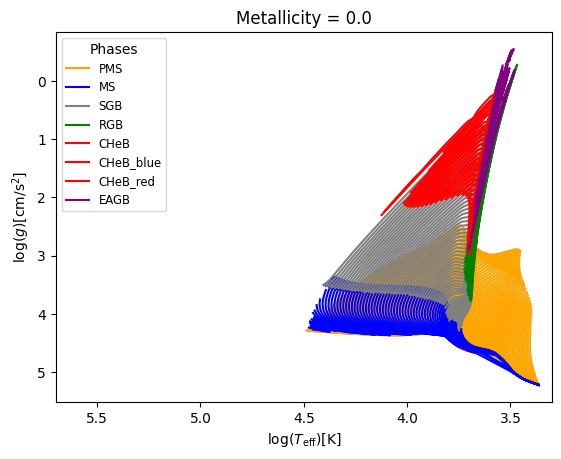

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.60000,4.4269,4.356,1.0,-0.25,9.714,0.535041
1,5.65000,4.4266,4.355,1.0,-0.25,9.714,0.535800
2,5.70000,4.4263,4.353,1.0,-0.25,9.714,0.536558
3,5.75000,4.4061,4.358,1.0,-0.25,8.856,0.514282
4,5.75000,4.4260,4.352,1.0,-0.25,9.714,0.537441
...,...,...,...,...,...,...,...
321691,10.25002,3.6561,2.334,4.0,0.50,0.805,1.005181
321692,10.25002,3.6560,2.333,4.0,0.50,0.805,1.005609
321693,10.25002,3.6559,2.331,4.0,0.50,0.805,1.006466
321694,10.25002,3.6558,2.330,4.0,0.50,0.805,1.006894


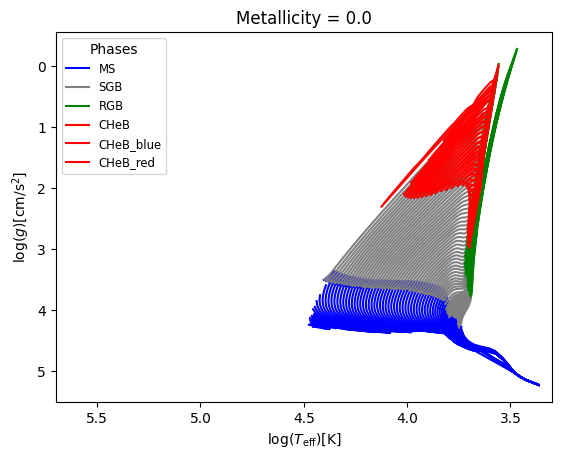

In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
print_all_uniques(phase_filtered_iso_df)

logAge  : Range : 5.3 - 10.25, Mean : 9.0428, Median : 9.3

logTe  : Range : 3.36 - 4.5177, Mean : 3.7779, Median : 3.721

logg  : Range : -0.38 - 5.345, Mean : 2.7607, Median : 2.486

Values in label column : 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.25, -2.5, -2.75, 0.0, 0.25, 0.5 

Mass  : Range : 0.09 - 13.952, Mean : 2.6725, Median : 1.428

Rpol  : Range : -0.98 - 2.8373, Mean : 0.9648, Median : 1.0158



In [9]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'logTe', 'logg', 'metallicity'], 
                               y_cols=['Mass', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the Mass parameter : 0.09 - 13.943
Median value in train data for the Mass parameter: 1.427
Mean value in train data for the Mass parameter: 2.674483292715276

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.8372727025023003
Median value in train data for the Rpol parameter: 1.015778756389041
Mean value in train data for the Rpol parameter: 0.9646120024510401

Testing set statistics:
Range in test data for the Mass parameter : 0.09 - 13.952
Median value in test data for the Mass parameter: 1.43
Mean value in test data for the Mass parameter: 2.6664658683974936

Range in test data for the Rpol parameter : -0.9763360818022064 - 2.831997677235896
Median value in test data for the Rpol parameter: 1.015778756389041
Mean value in test data for the Rpol parameter: 0.9652648999427869

(241272, 4) (80424, 4)
(241272, 2) (80424, 2)


## Model training

### Linear regression

In [10]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.7140803707653698
  RMSE :  1.6260706065841914
  MAE :  1.3562018118192738
  MedAE :  1.2151522118100613
  CORR :  0.8773843227443289
  MAX_ER :  5.8090228093953264
  Percentiles : 
    75th percentile :  1.9209920410788994
    90th percentile :  2.5074255700541306
    95th percentile :  2.9477708333463446
    99th percentile :  4.1345272229892025

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.8170987684749774
  RMSE :  1.4568068548856574
  MAE :  1.080739249306271
  MedAE :  0.8784675623561893
  CORR :  0.9105157535025173
  MAX_ER :  5.531744924051363
  Percentiles : 
    75th percentile :  1.1846194187050147
    90th percentile :  2.1507340911368646
    95th percentile :  3.427355530763702
    99th percentile :  4.822304718580461

mass

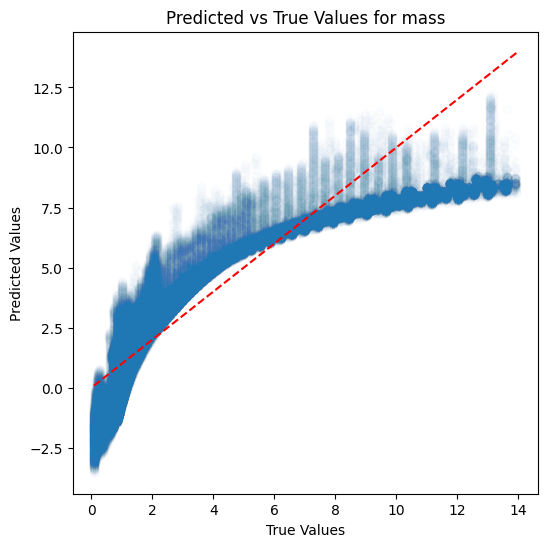

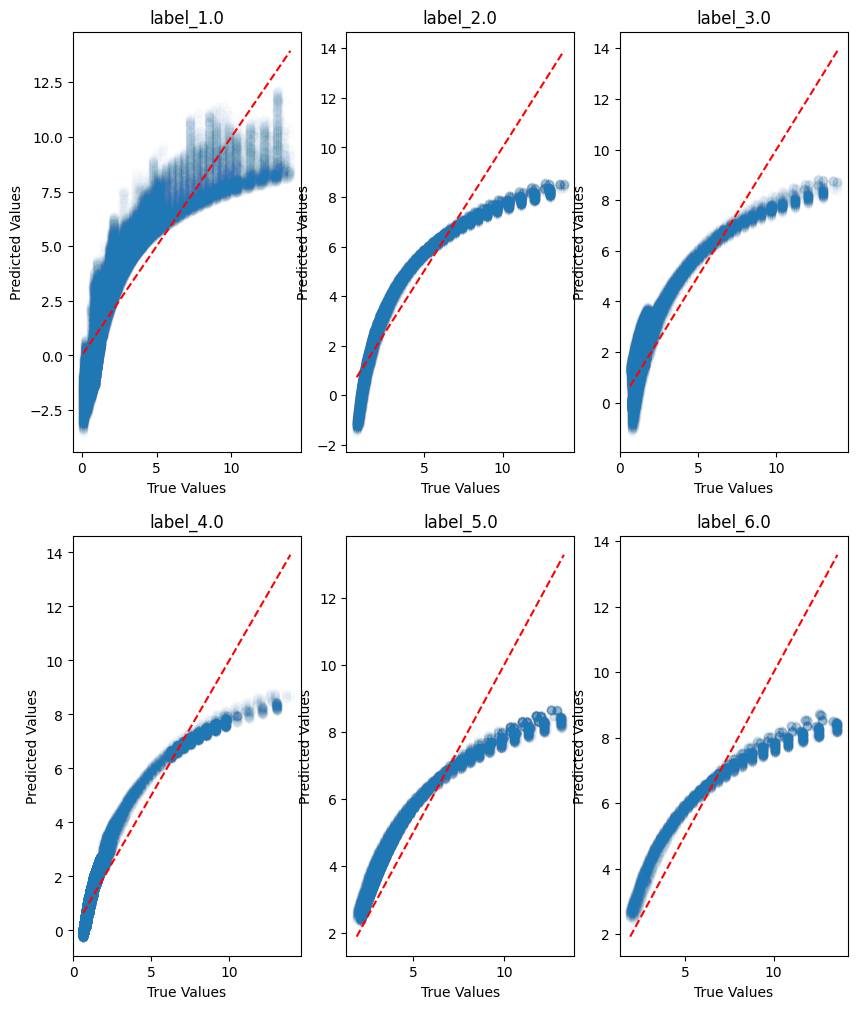

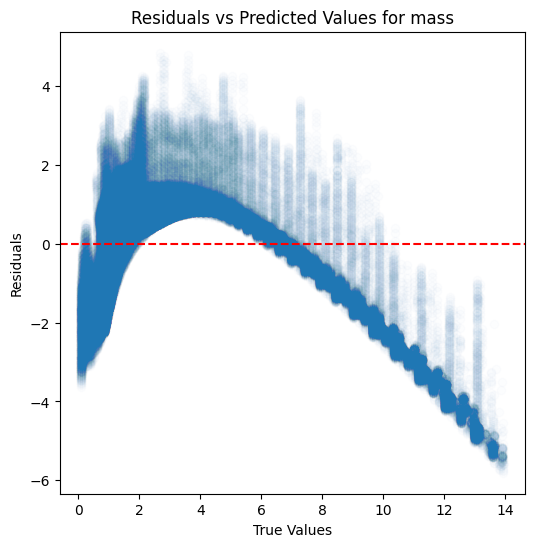

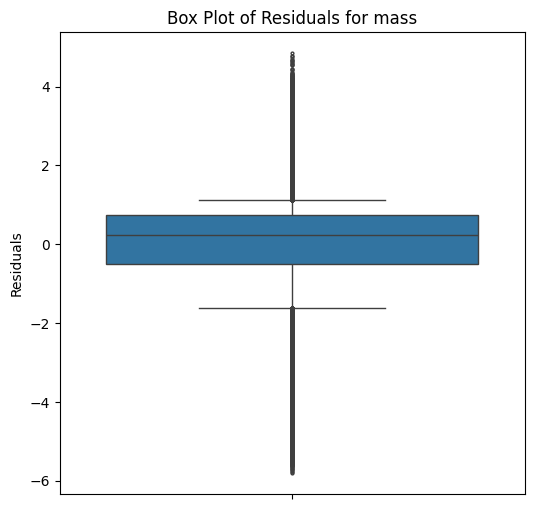

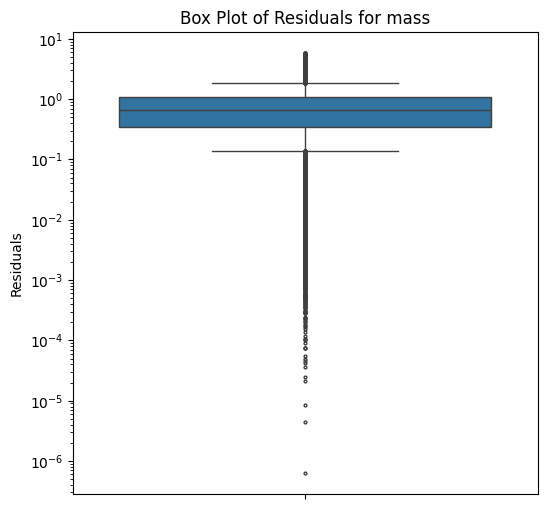

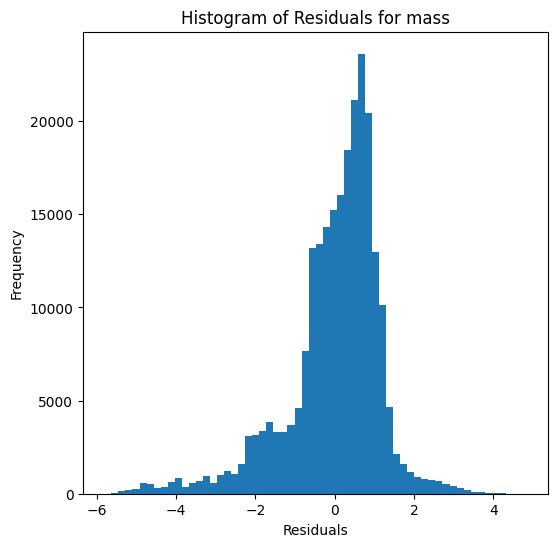

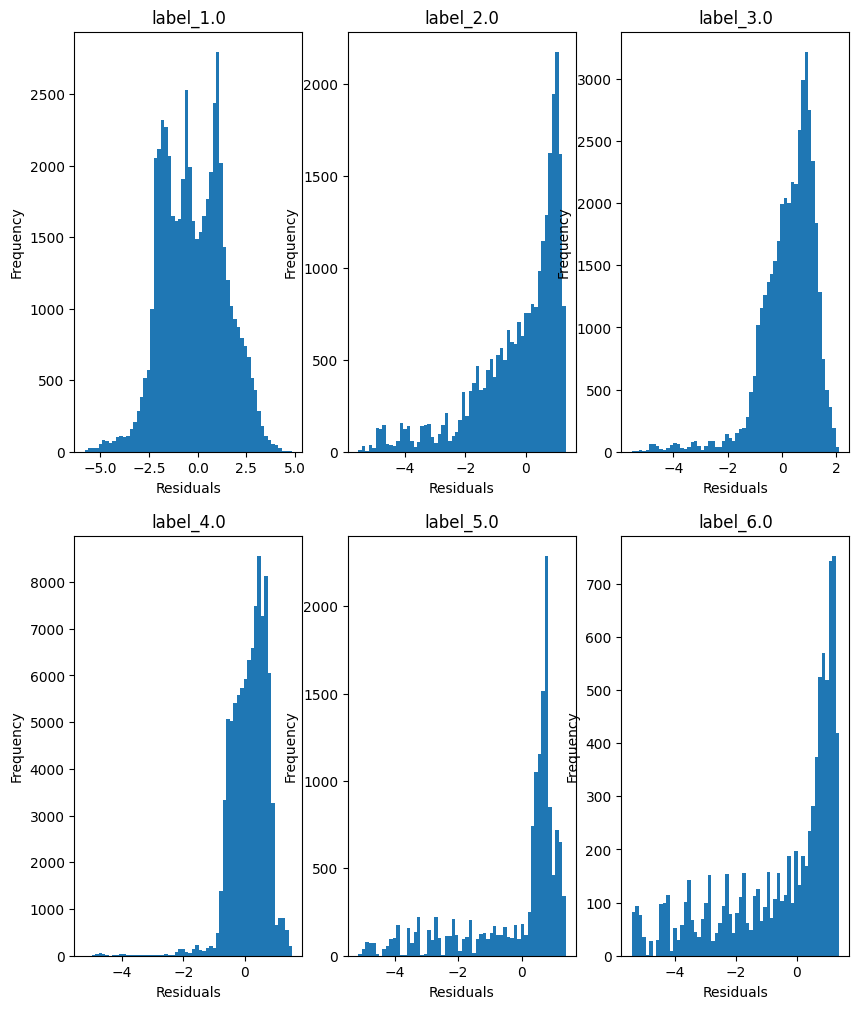

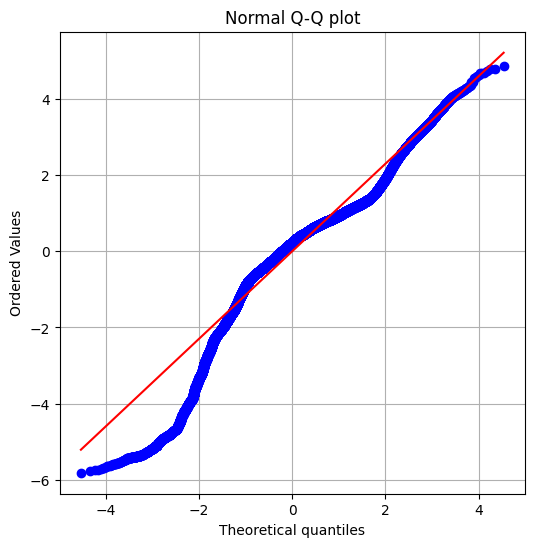

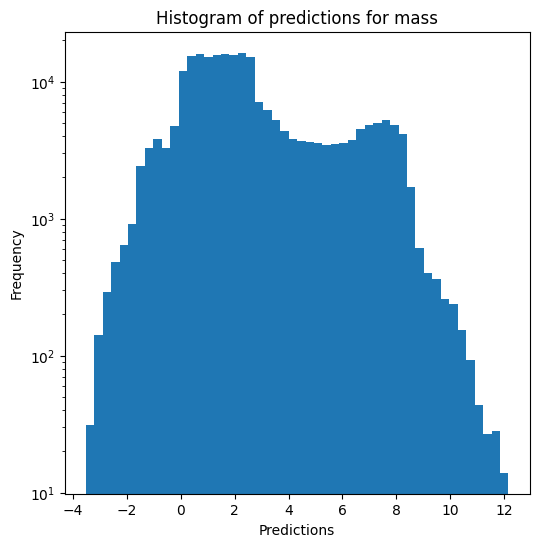

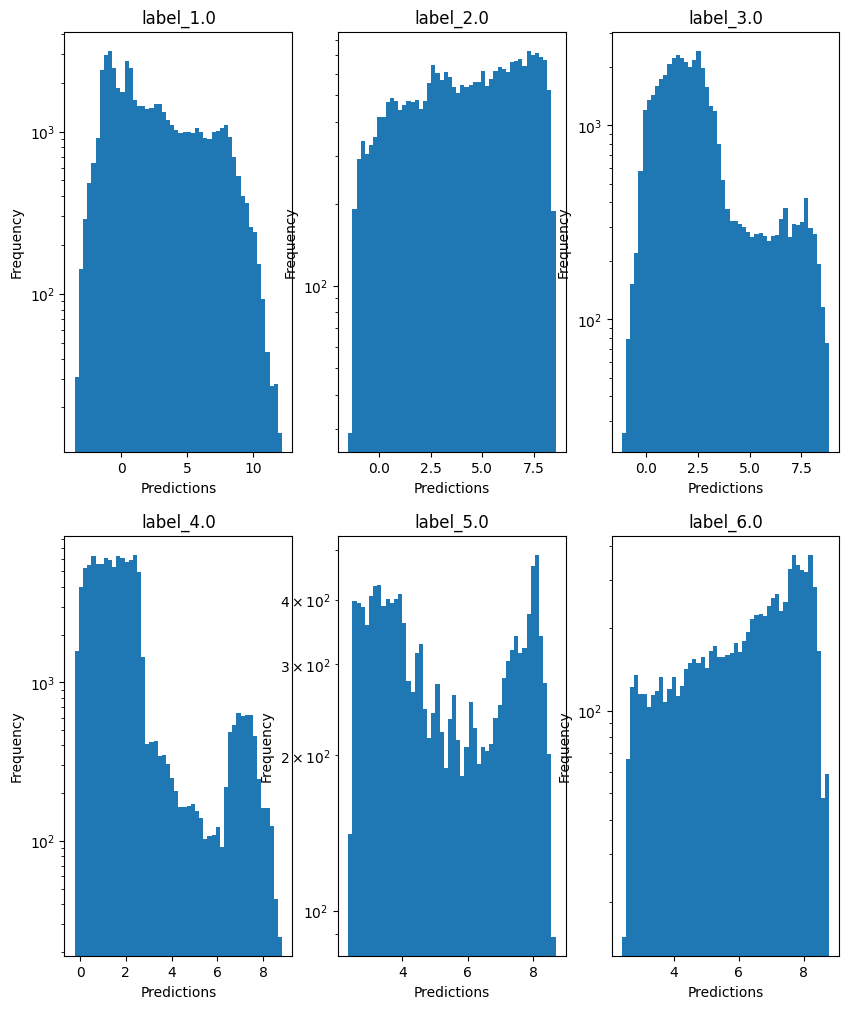

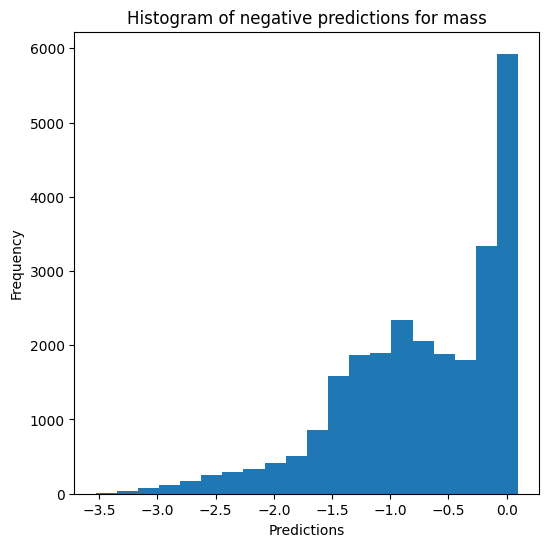


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9484107826824841
  RMSE :  0.08328587325029772
  MAE :  0.06347474231029848
  MedAE :  0.053154978755494124
  CORR :  0.973870221001157
  MAX_ER :  0.35066724349697864
  Percentiles : 
    75th percentile :  0.08970545471741609
    90th percentile :  0.11906427683749629
    95th percentile :  0.16799917501830414
    99th percentile :  0.26840410422595773

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9977700166955079
  RMSE :  0.038903834702840534
  MAE :  0.030590827136255726
  MedAE :  0.025142574806393758
  CORR :  0.9991018210196537
  MAX_ER :  0.11589185744683808
  Percentiles : 
    75th percentile :  0.04434843035667663
    90th percentile :  0.066657840341061
    95th percentile :  0.07914560411328202
    99th percentile :  0.09843326758111018

radius results for the label c

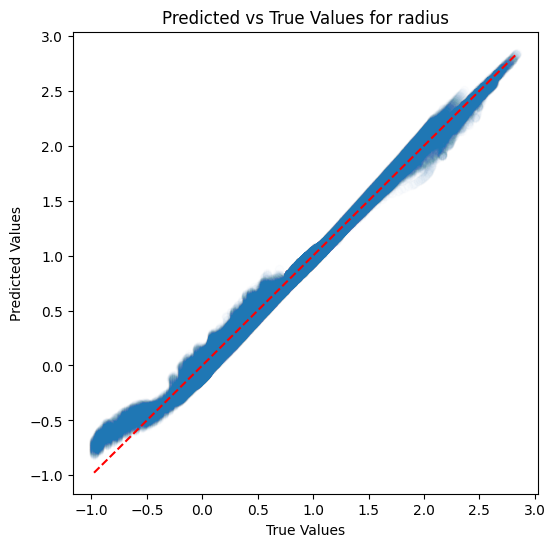

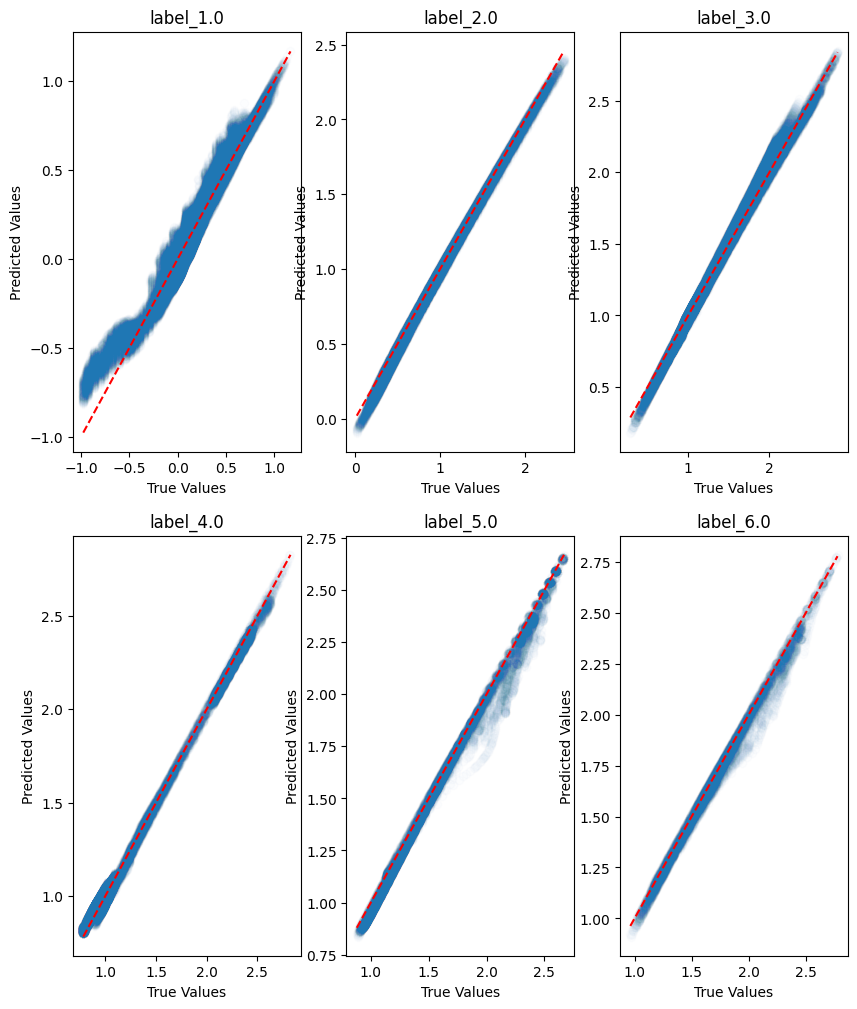

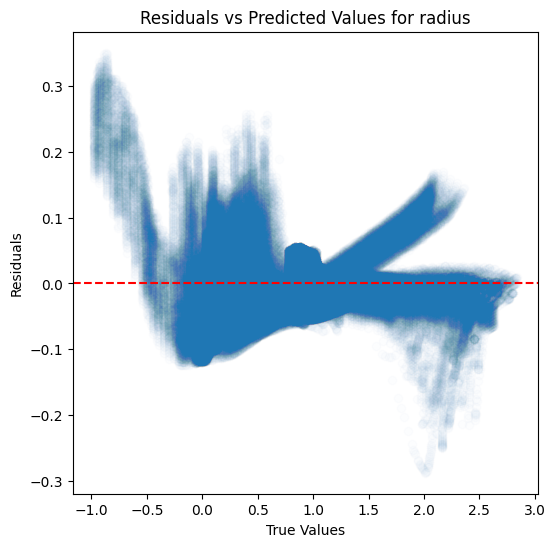

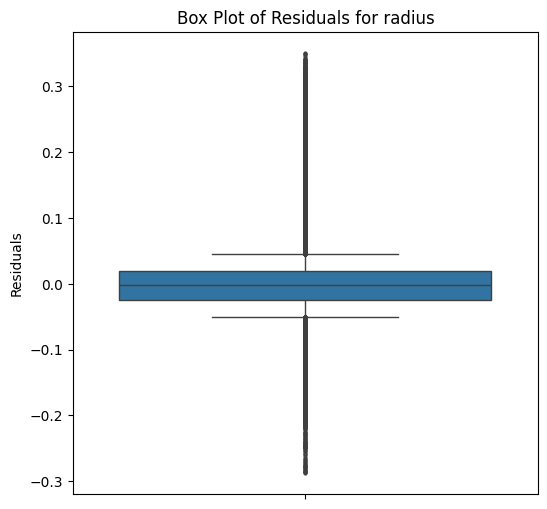

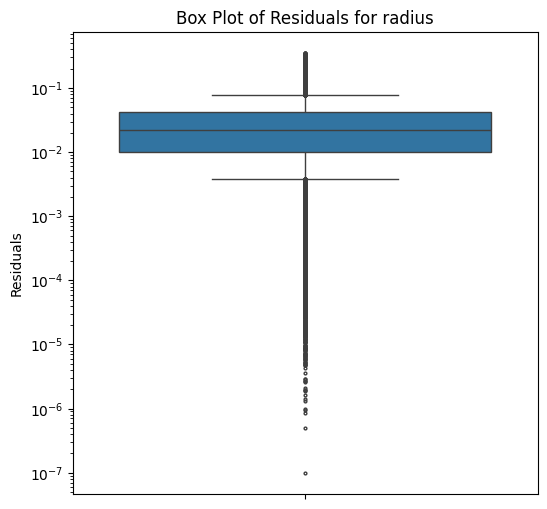

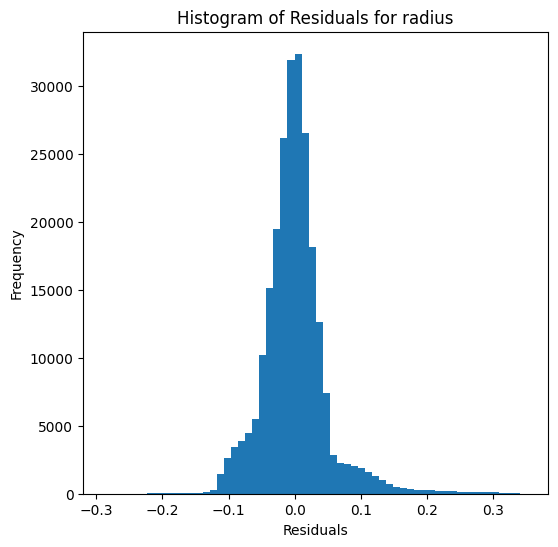

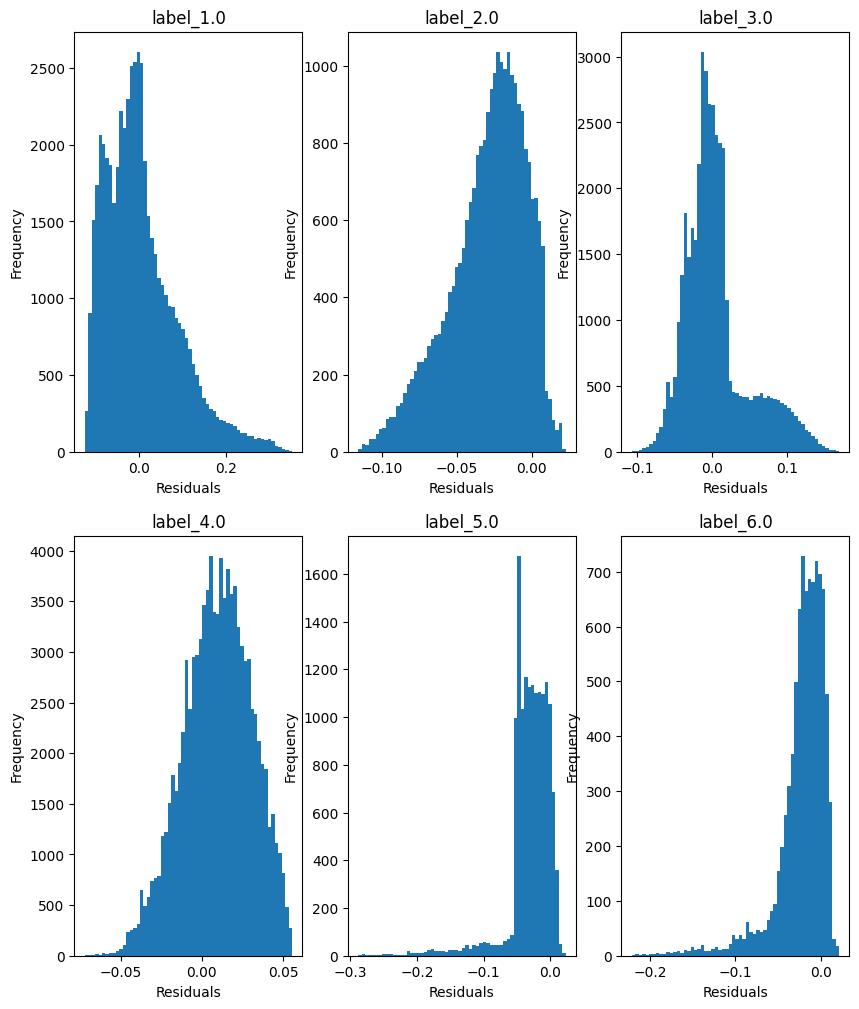

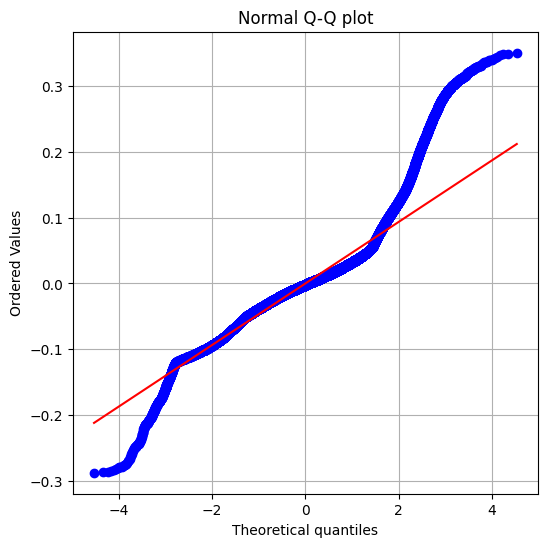

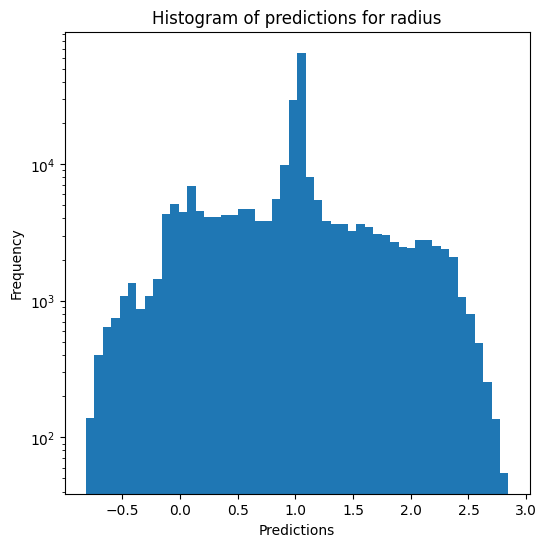

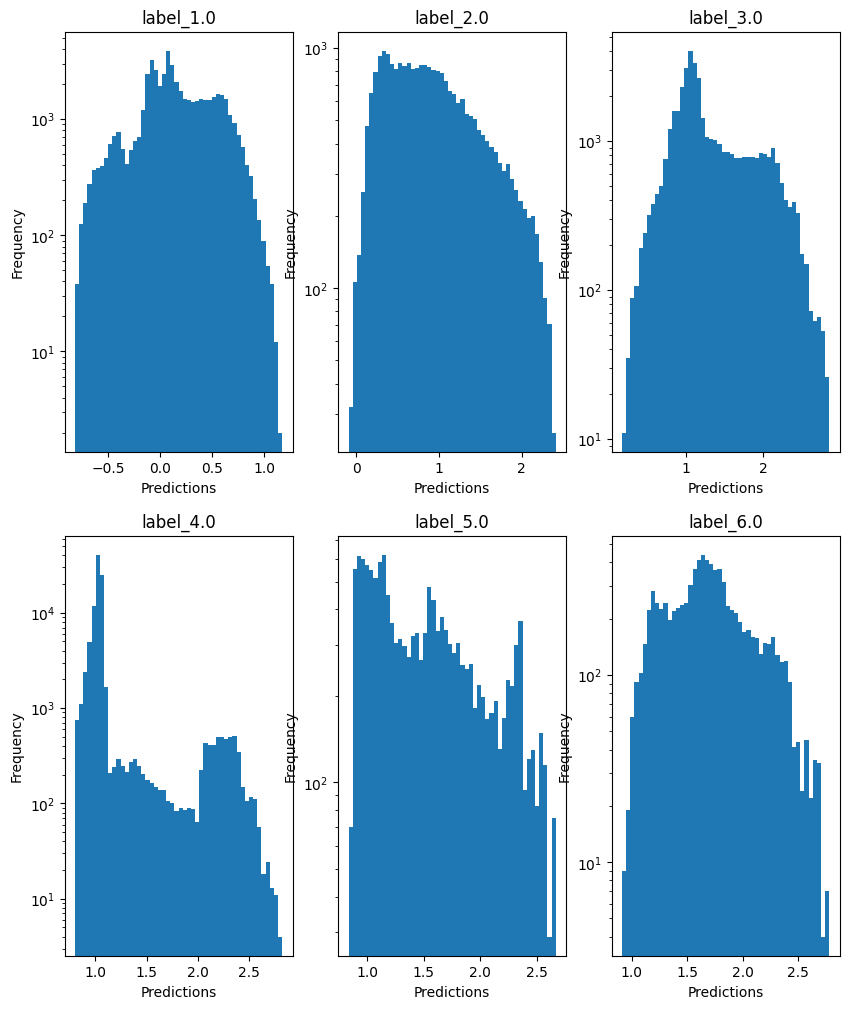

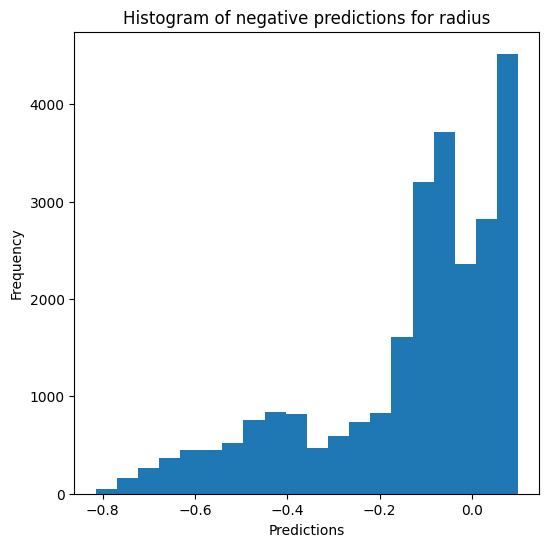

Saving predictions and results...


In [11]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True

### Decision tree

In [12]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9996199394604536
  RMSE :  0.058828560562479454
  MAE :  0.013624115953093928
  MedAE :  0.0
  CORR :  0.9998099718026763
  MAX_ER :  1.3419999999999987
  Percentiles : 
    75th percentile :  0.0010000000000000009
    90th percentile :  0.021500000000000075
    95th percentile :  0.0690000000000004
    99th percentile :  0.29299999999999926

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999435053268252
  RMSE :  0.025202743655011756
  MAE :  0.006441006664600152
  MedAE :  0.0
  CORR :  0.9999718603342423
  MAX_ER :  0.7729999999999997
  Percentiles : 
    75th percentile :  0.0009999999999994458
    90th percentile :  0.017000000000000126
    95th percentile :  0.041999999999999996
    99th percentile :  0.10200000000000031

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  RVE :  0.99991588440

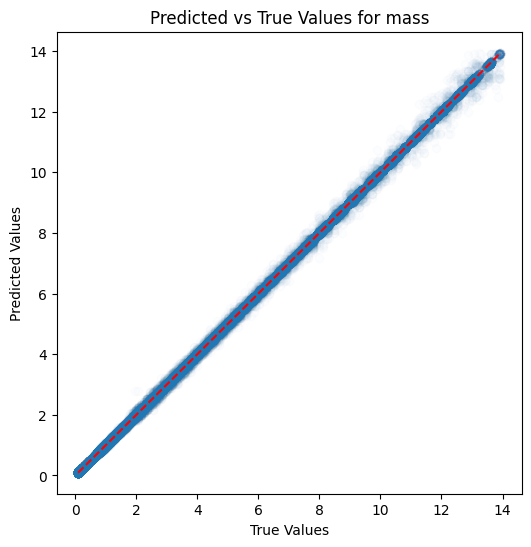

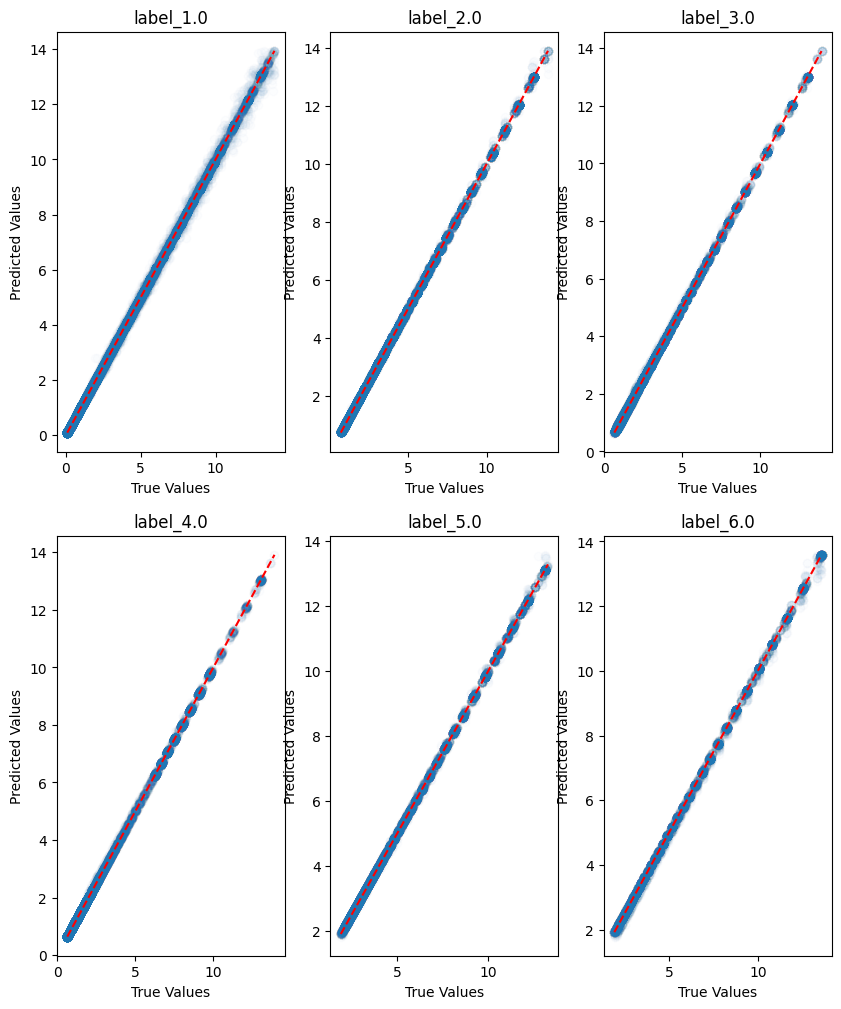

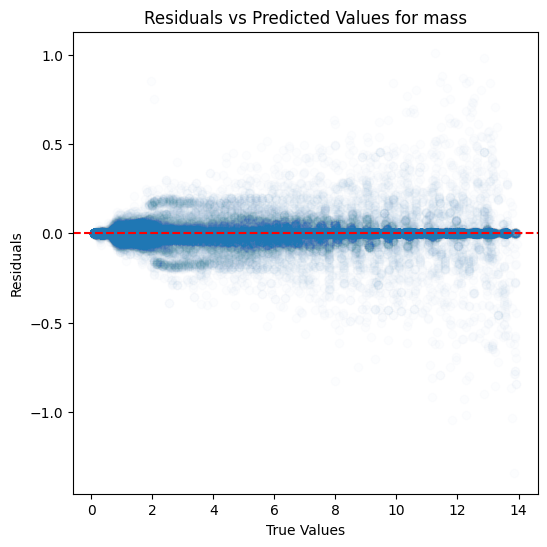

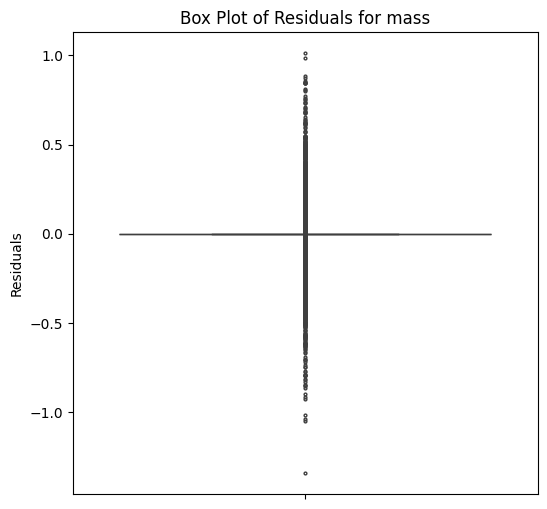

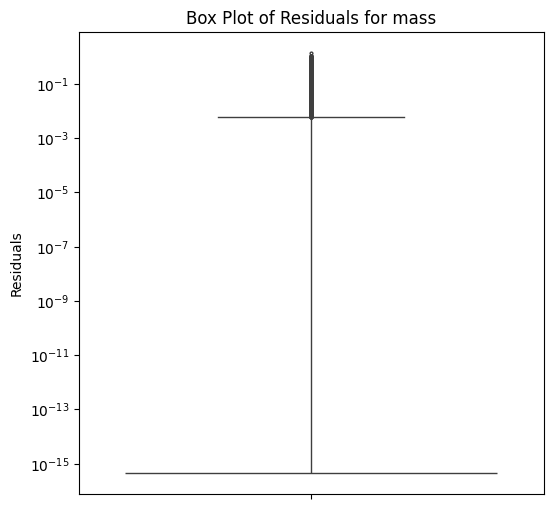

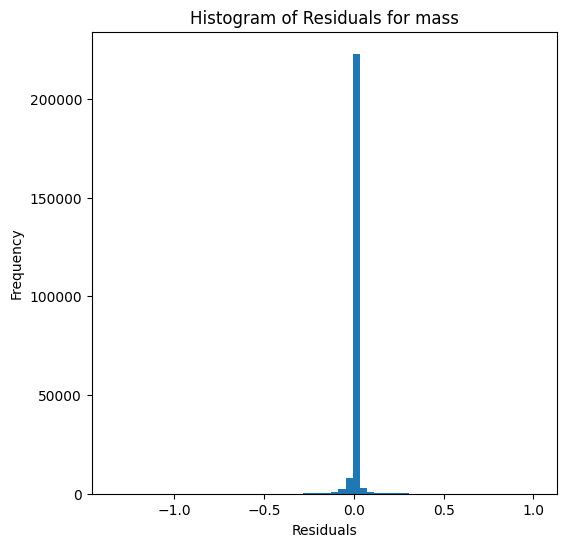

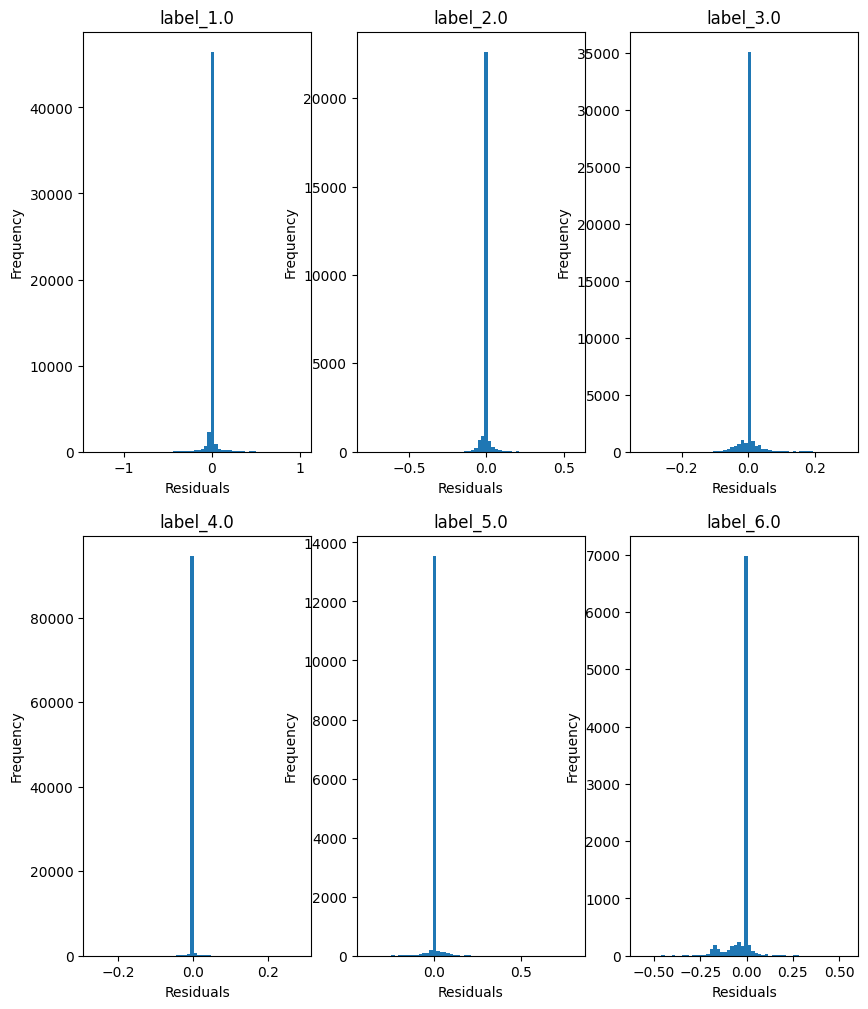

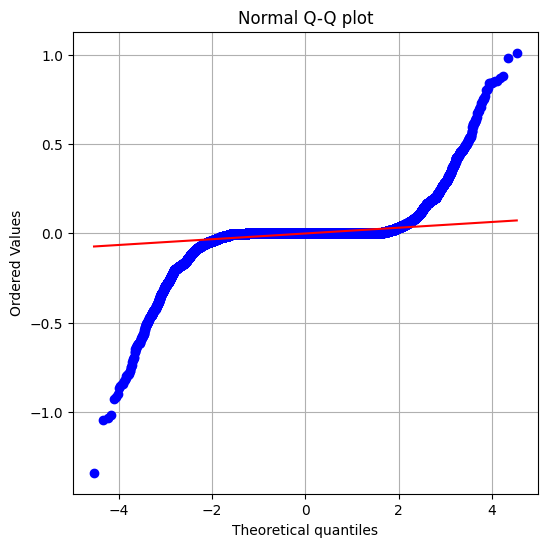

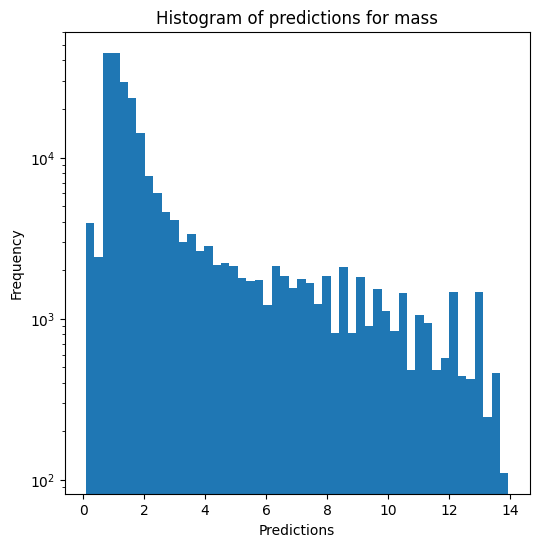

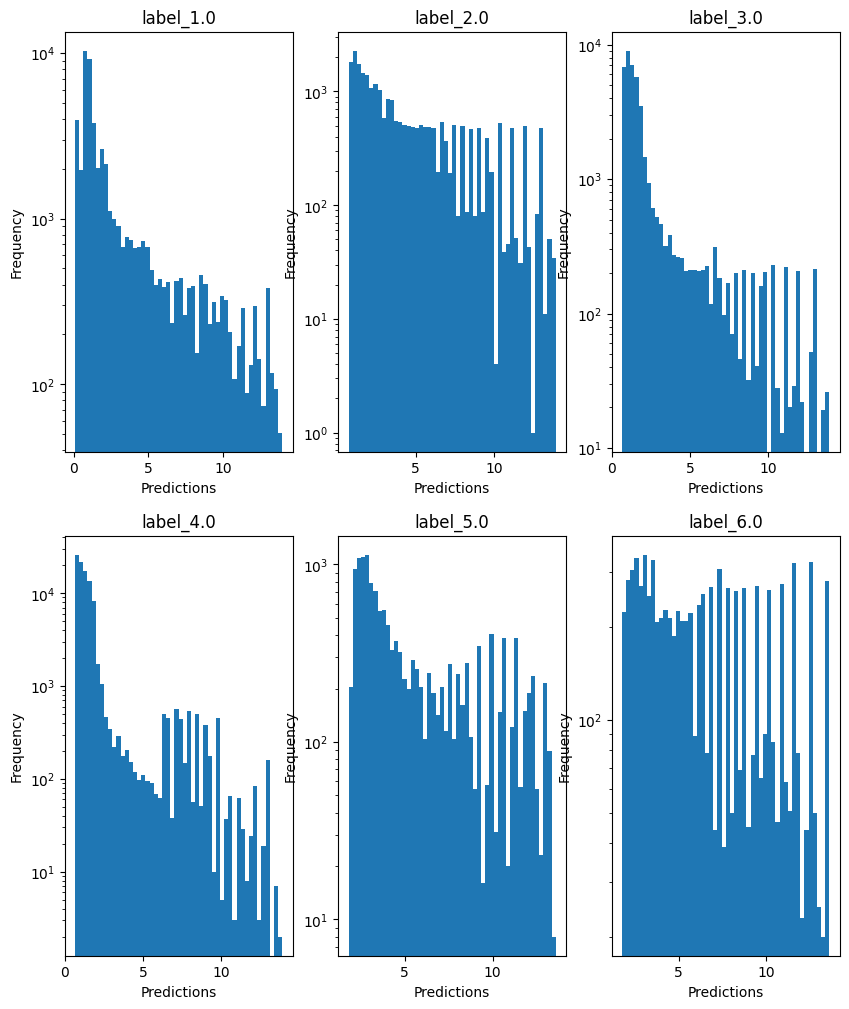

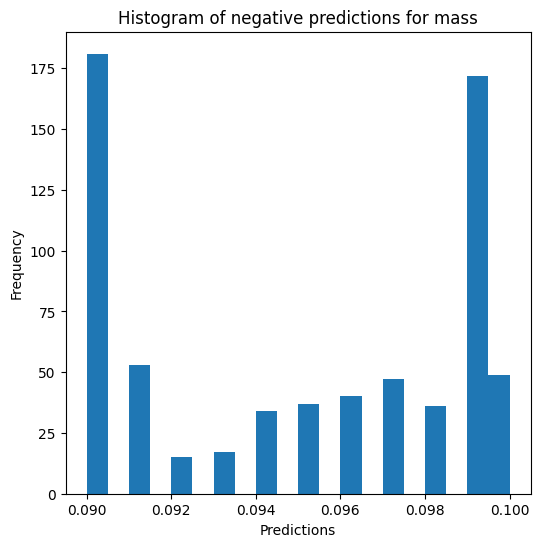

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9996533184198445
  RMSE :  0.006814472566933112
  MAE :  0.0025158826079985865
  MedAE :  2.7755575615628914e-17
  CORR :  0.9998267103998053
  MAX_ER :  0.11918640771920858
  Percentiles : 
    75th percentile :  0.0017253614990288427
    90th percentile :  0.007654759022728941
    95th percentile :  0.013803281142767103
    99th percentile :  0.03188525124910224

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9992694418974936
  RMSE :  0.014633925635527706
  MAE :  0.005604693961207325
  MedAE :  0.0
  CORR :  0.9996389857553007
  MAX_ER :  0.3374512485512551
  Percentiles : 
    75th percentile :  0.006666898301900509
    90th percentile :  0.01956646246229956
    95th percentile :  0.025753799888850893
    99th percentile :  0.0482640067829533

radius results for the label catego

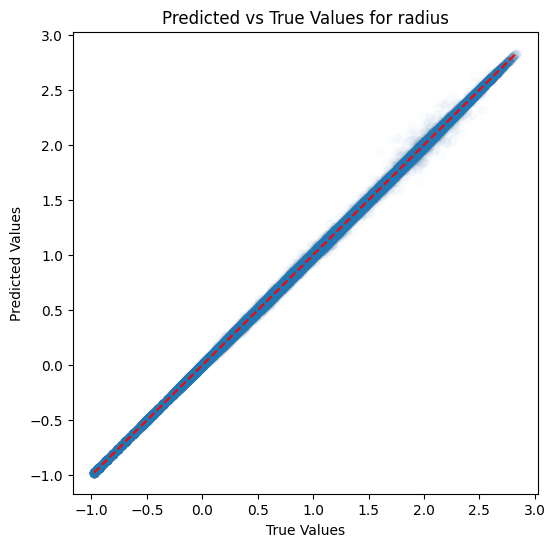

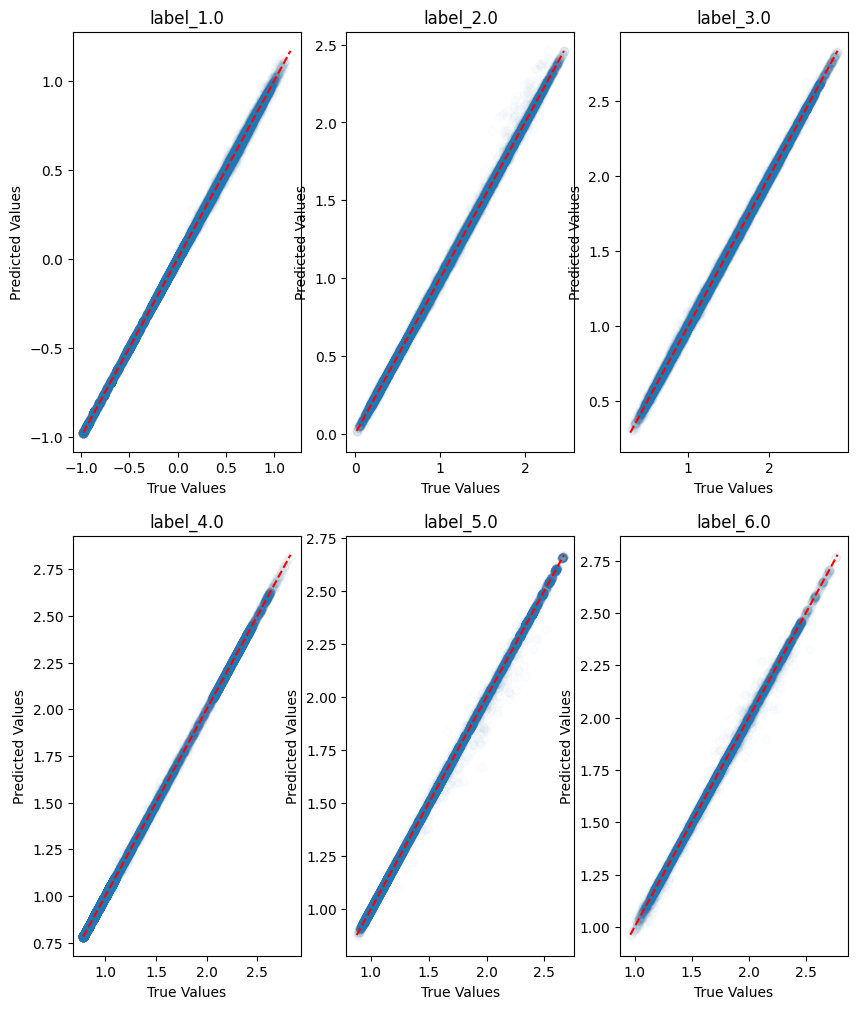

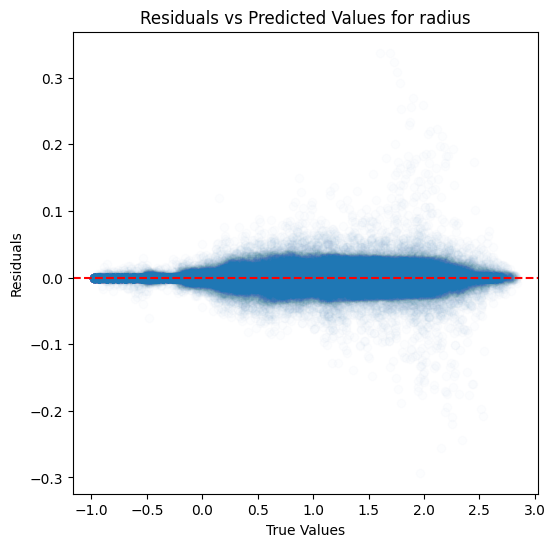

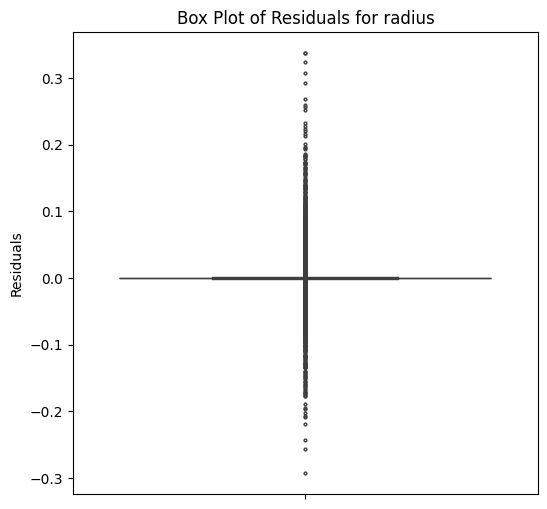

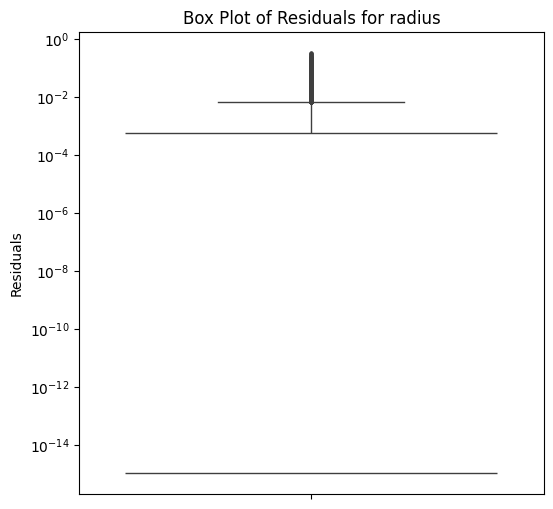

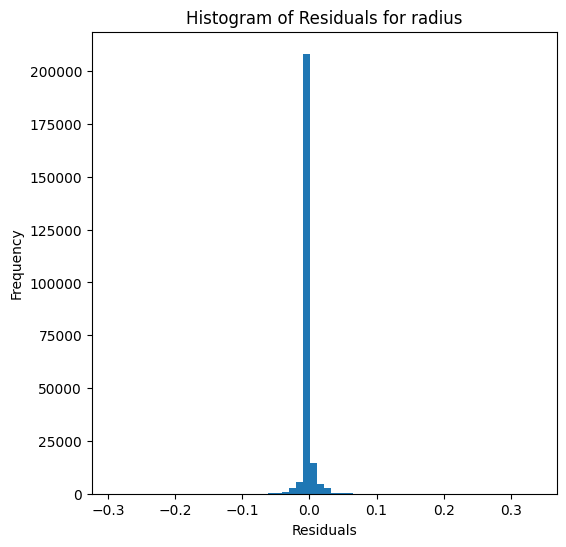

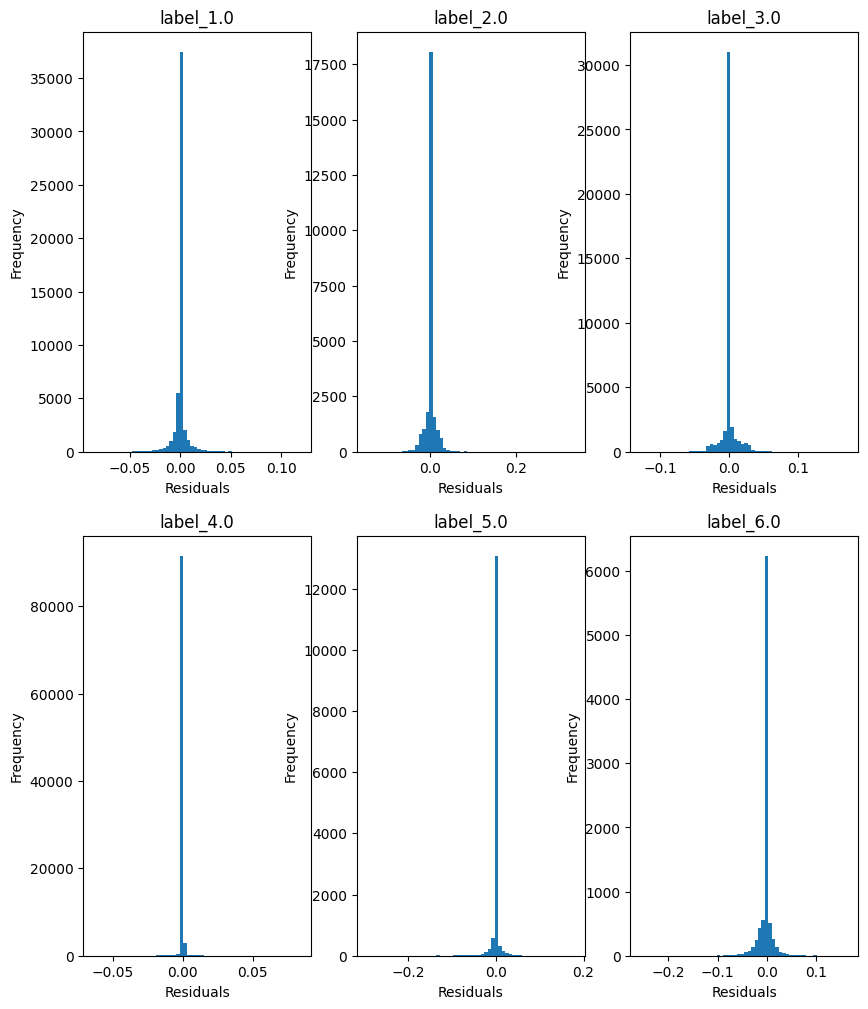

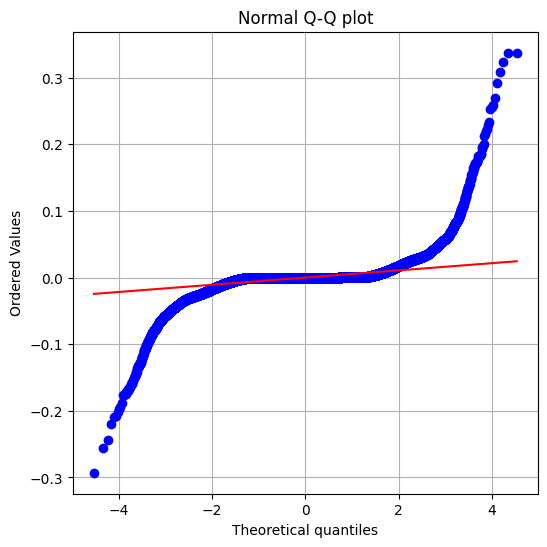

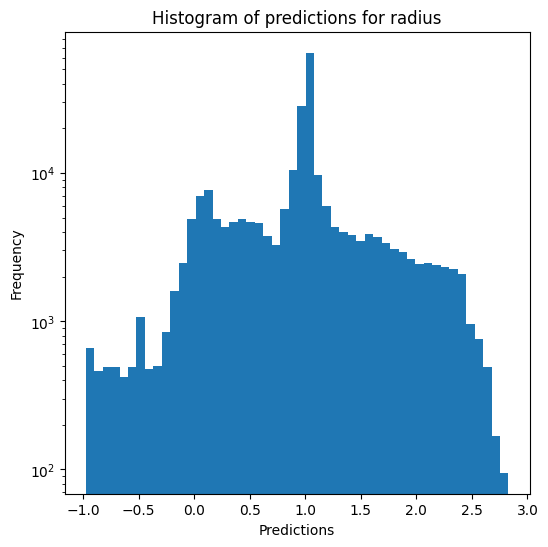

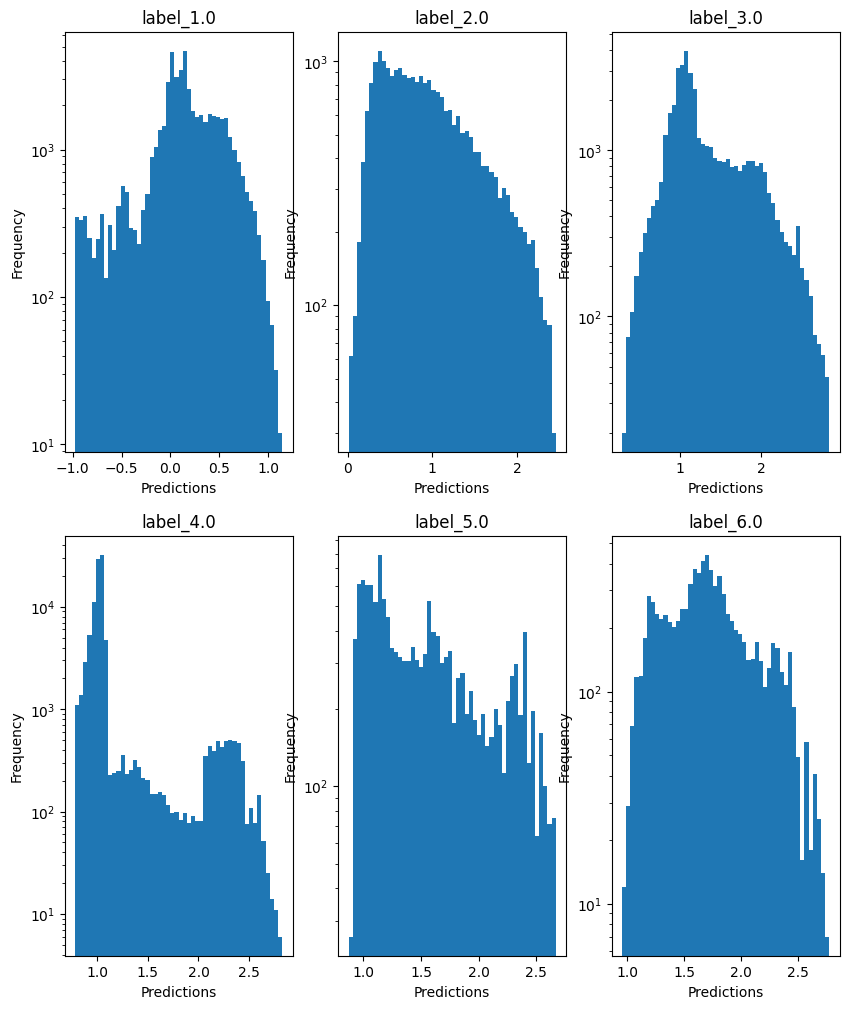

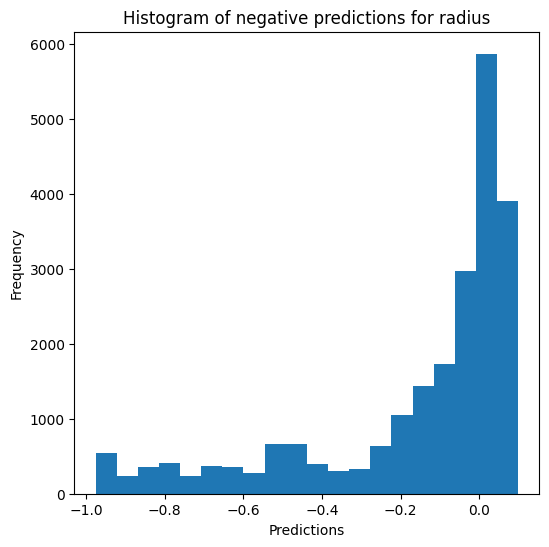

Saving predictions and results...


In [13]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### K-nearest neighbours

In [14]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9992330393843977
  RMSE :  0.08357369463474296
  MAE :  0.03259548193912747
  MedAE :  0.005599999999999994
  CORR :  0.9996189971600283
  MAX_ER :  1.4042000000000012
  Percentiles : 
    75th percentile :  0.027599999999999847
    90th percentile :  0.08919999999999995
    95th percentile :  0.16080000000000005
    99th percentile :  0.3734699999999986

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.995582059544364
  RMSE :  0.22840643115493142
  MAE :  0.1062711407315561
  MedAE :  0.031400000000000095
  CORR :  0.9981647530890561
  MAX_ER :  2.5532000000000004
  Percentiles : 
    75th percentile :  0.10299999999999987
    90th percentile :  0.28220000000000045
    95th percentile :  0.4983899999999989
    99th percentile :  1.0283859999999978

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  

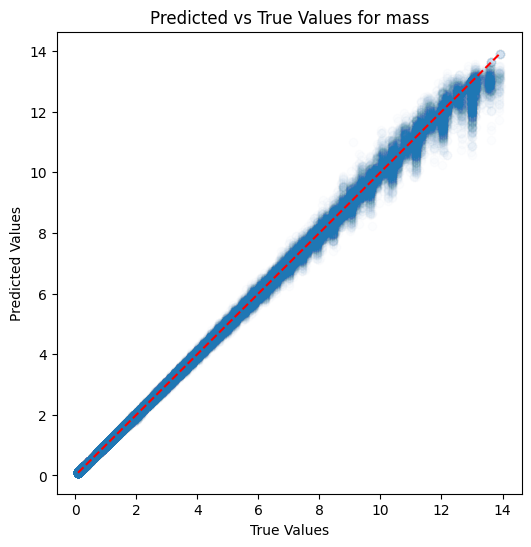

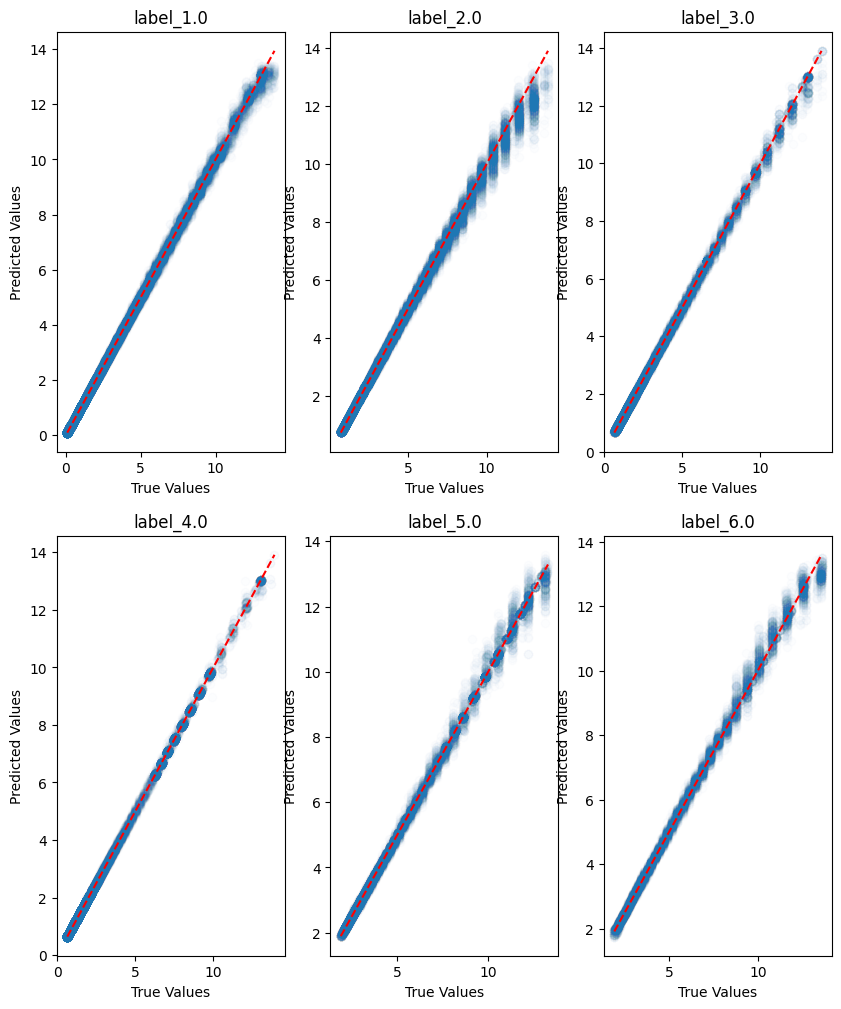

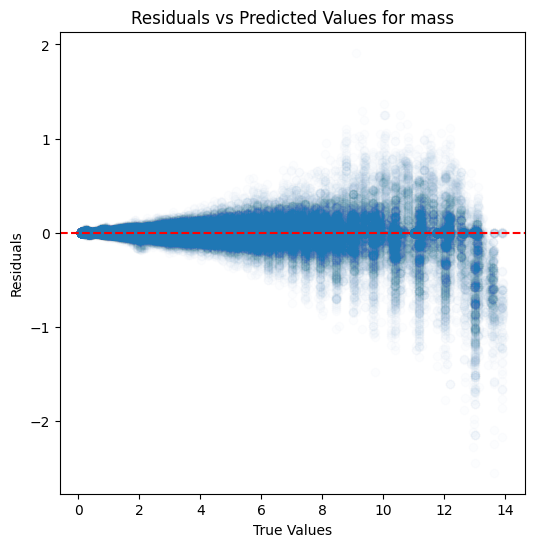

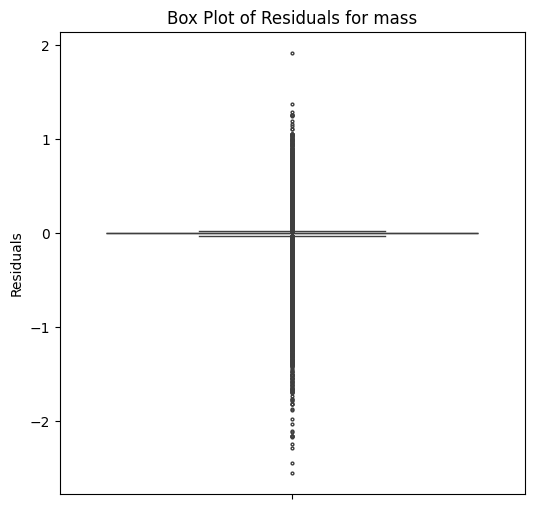

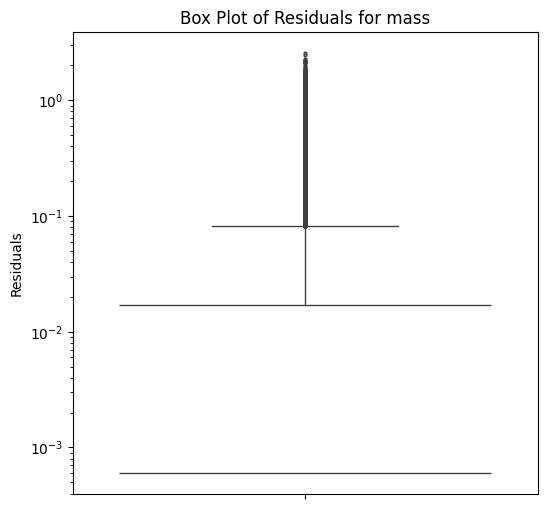

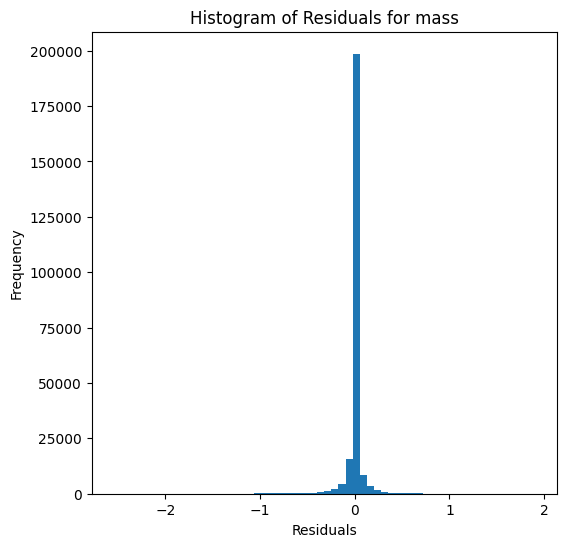

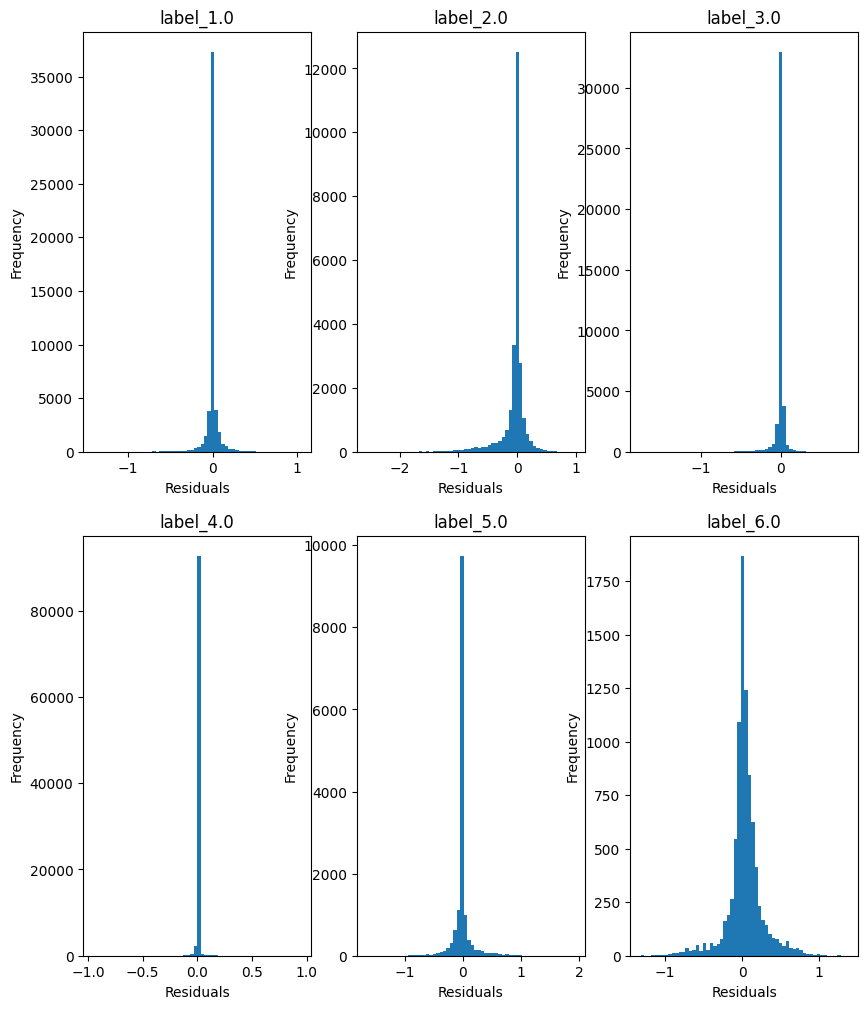

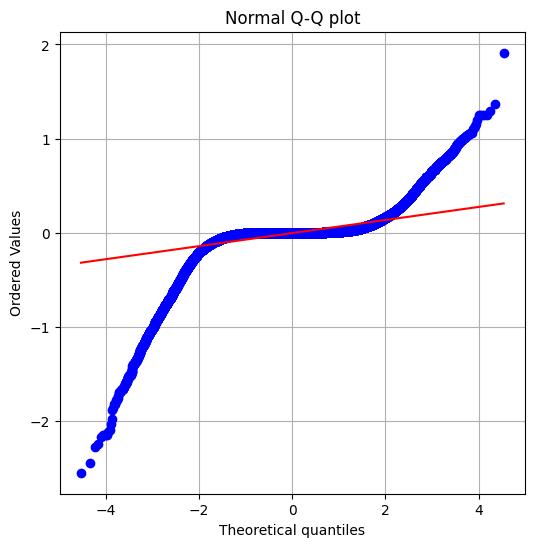

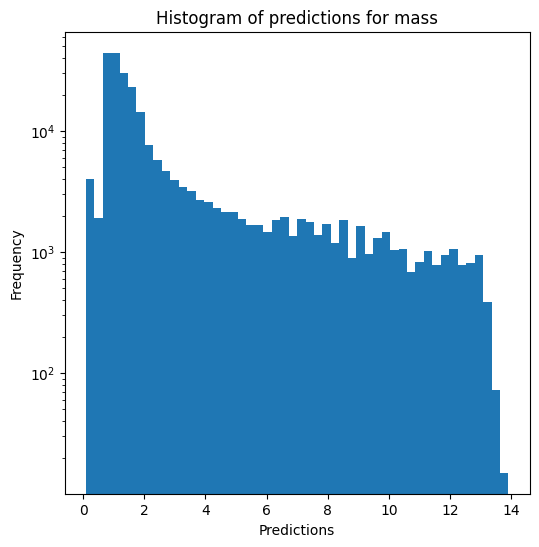

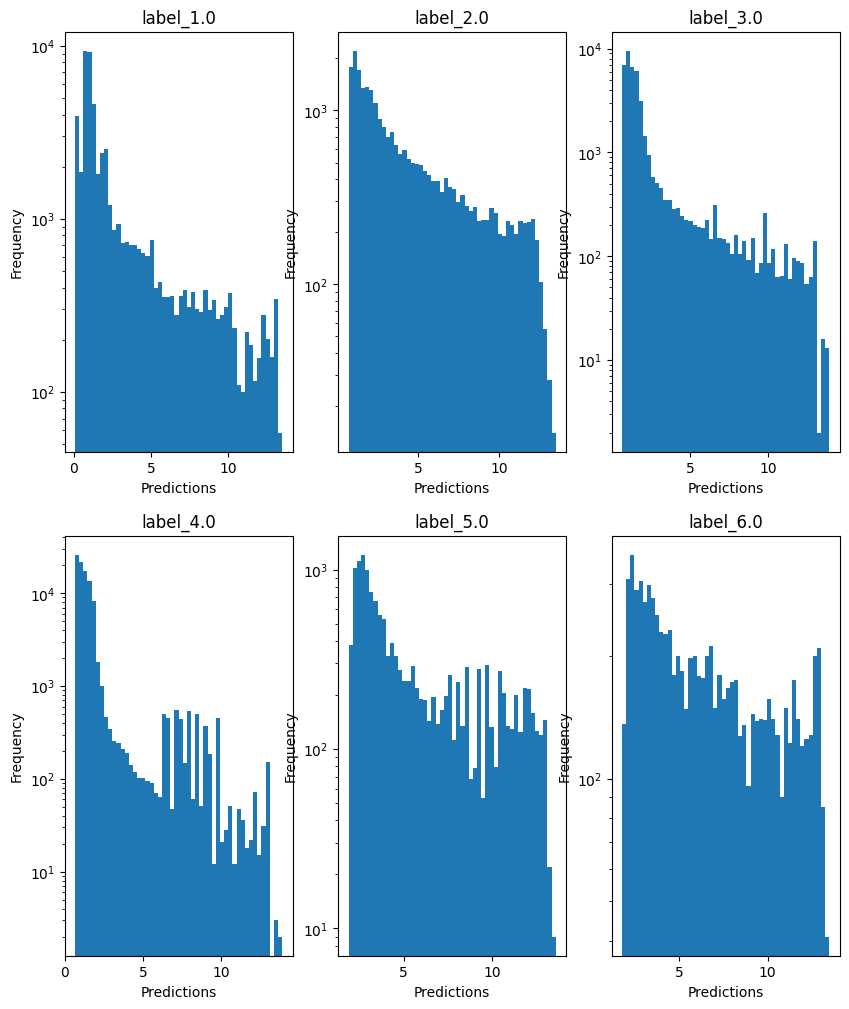

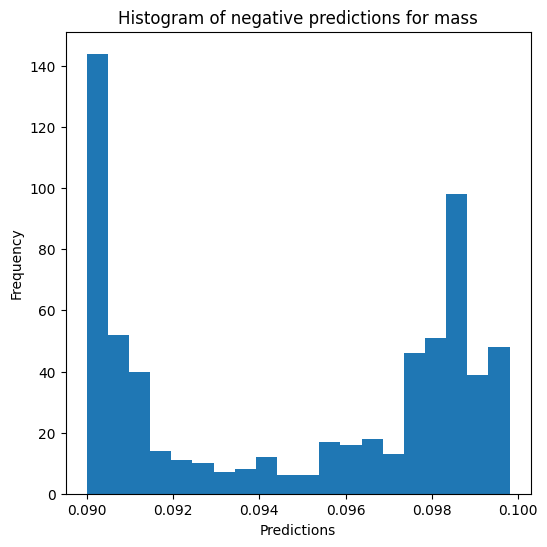


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9994564480463575
  RMSE :  0.008571119934515299
  MAE :  0.005303226431220142
  MedAE :  0.0027441352709844935
  CORR :  0.9997281908010512
  MAX_ER :  0.06816868237432583
  Percentiles : 
    75th percentile :  0.00733360630594182
    90th percentile :  0.014165883269252555
    95th percentile :  0.019190111403417816
    99th percentile :  0.03069651463481125

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9989935477327837
  RMSE :  0.017161217343401477
  MAE :  0.011598734666001727
  MedAE :  0.008321337142644158
  CORR :  0.9995151196254624
  MAX_ER :  0.2239638252329752
  Percentiles : 
    75th percentile :  0.015511513419931233
    90th percentile :  0.02451782407704101
    95th percentile :  0.03129507919070873
    99th percentile :  0.053893621989201446

radius results for th

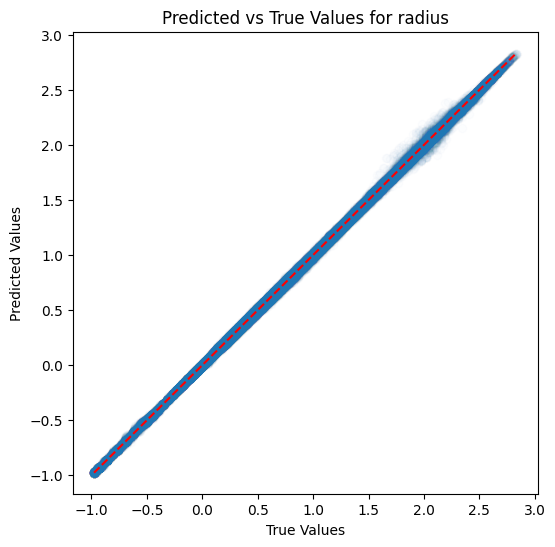

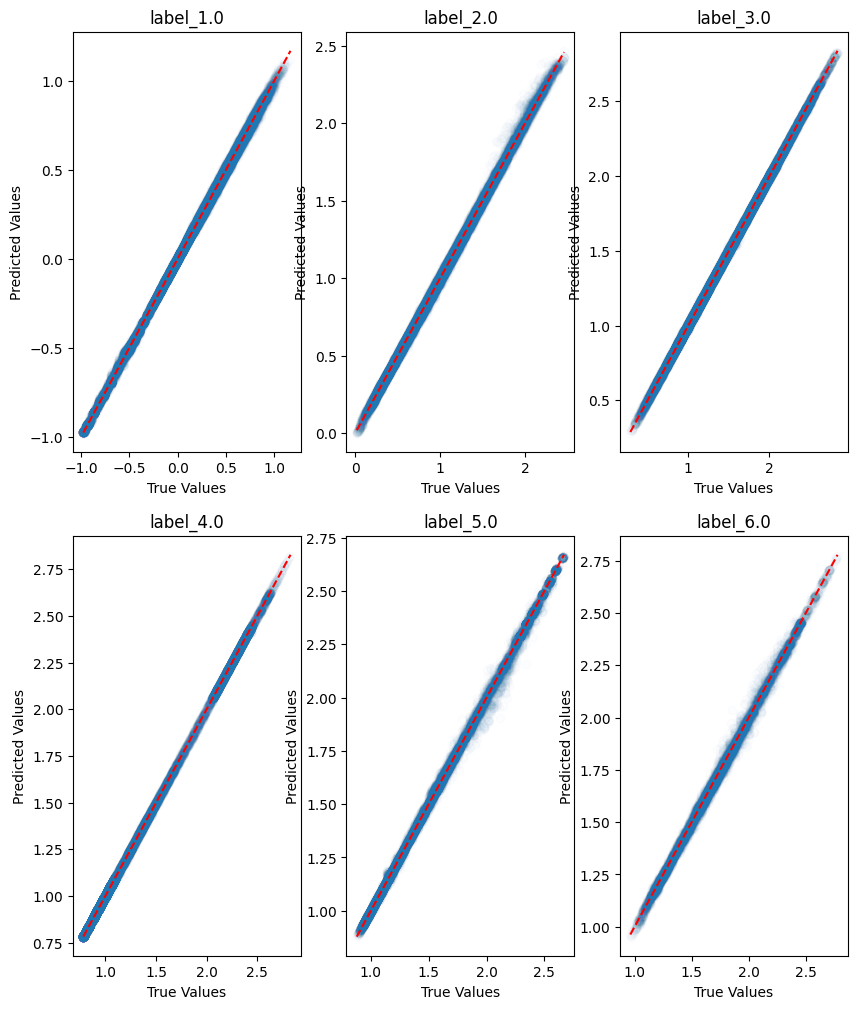

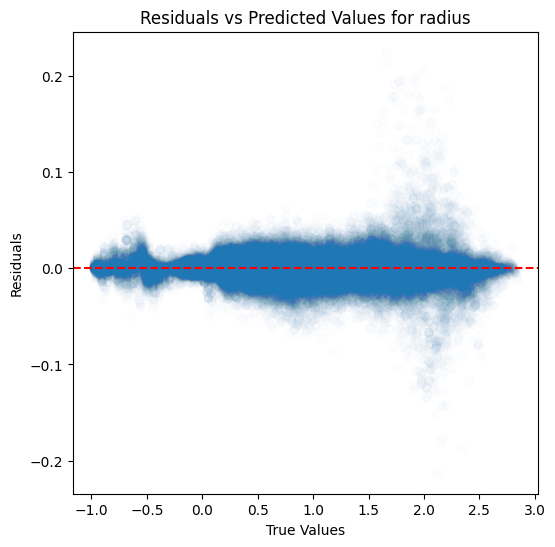

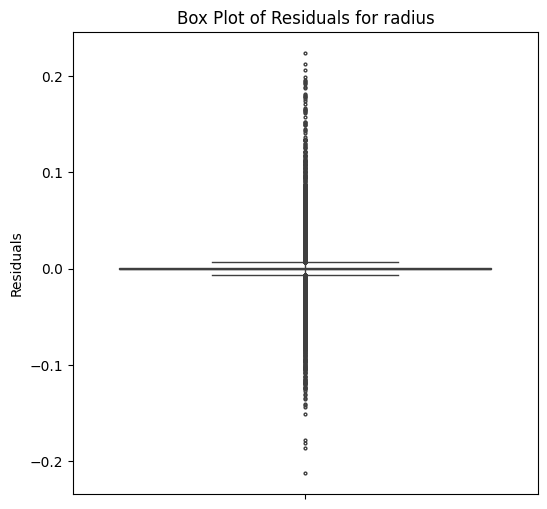

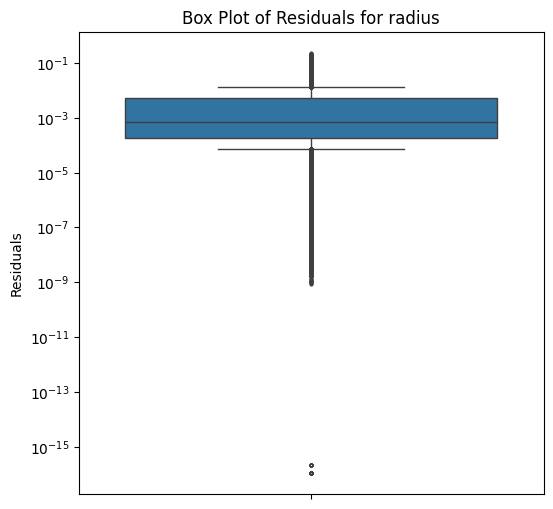

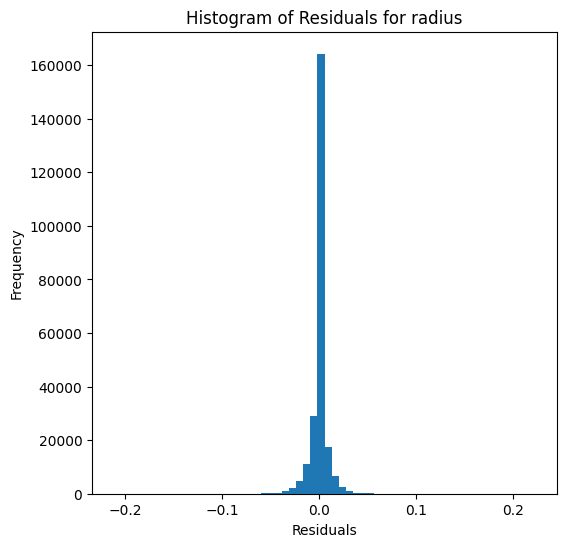

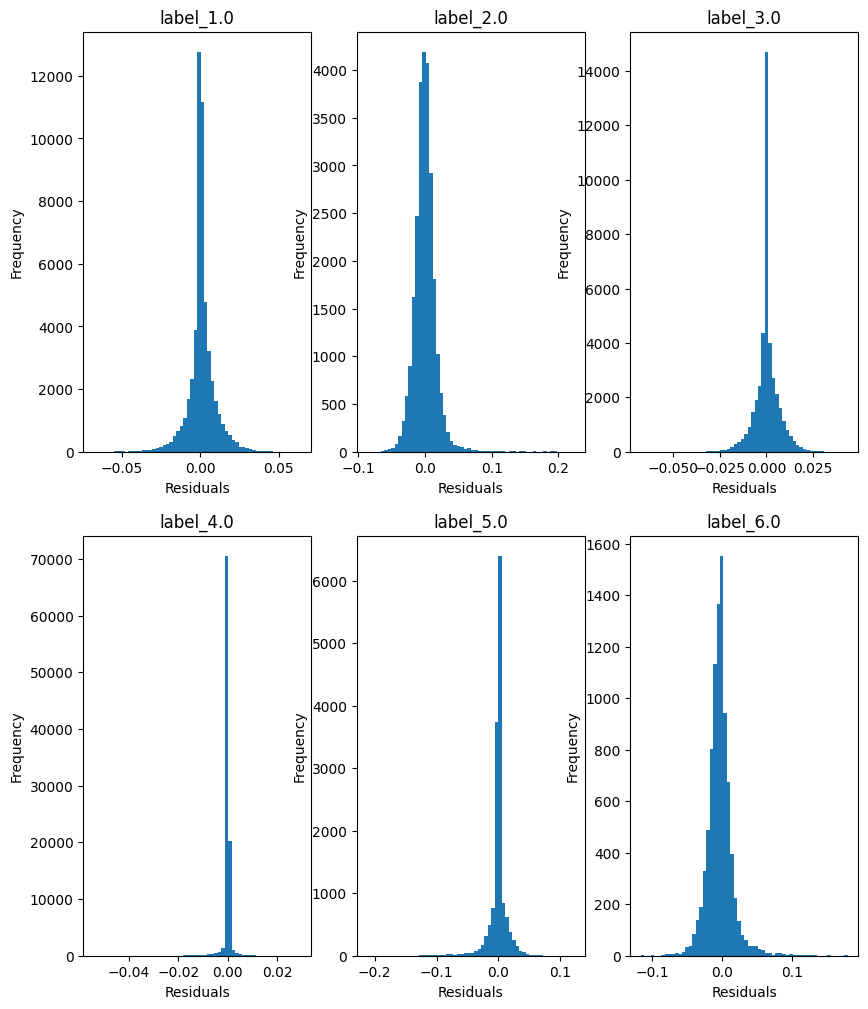

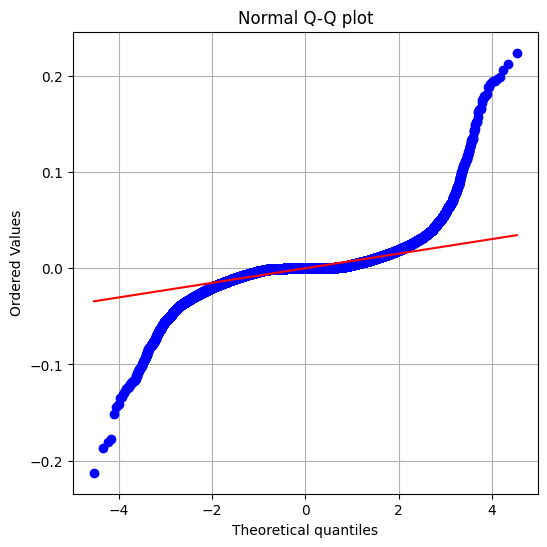

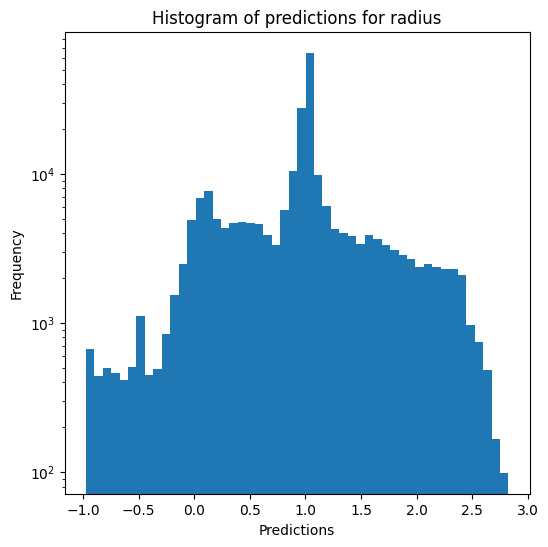

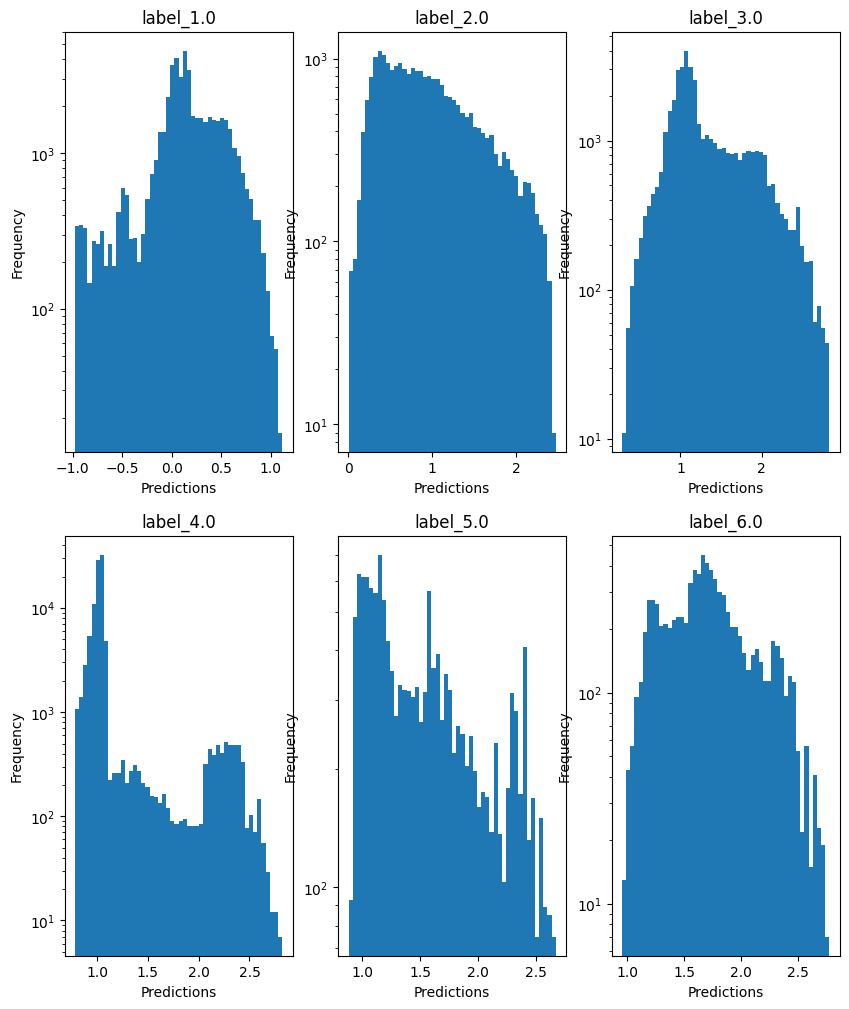

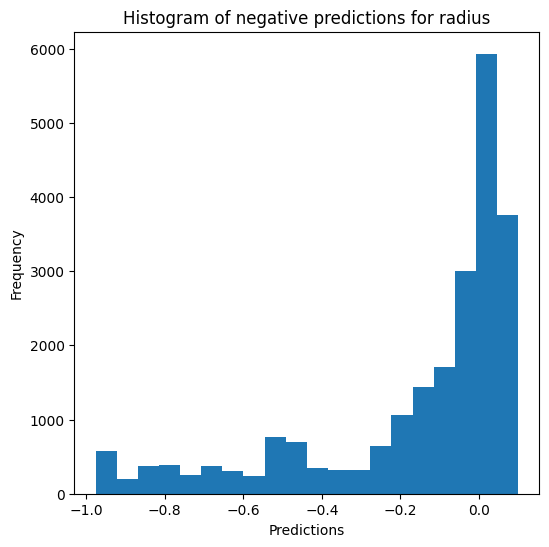

Saving predictions and results...


In [15]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [16]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9998821431793583
  RMSE :  0.03276031196650742
  MAE :  0.0087090023498963
  MedAE :  0.00026999999998800206
  CORR :  0.9999410925272434
  MAX_ER :  0.7763299999999891
  Percentiles : 
    75th percentile :  0.003350000000000436
    90th percentile :  0.019180000000000752
    95th percentile :  0.044257500000001726
    99th percentile :  0.15242350000000335

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.999972327434033
  RMSE :  0.017650094978825095
  MAE :  0.006938535679229601
  MedAE :  0.0005749999999924427
  CORR :  0.9999862194792069
  MAX_ER :  0.5069500000000069
  Percentiles : 
    75th percentile :  0.006799999999996864
    90th percentile :  0.021799999999996888
    95th percentile :  0.03391999999999697
    99th percentile 

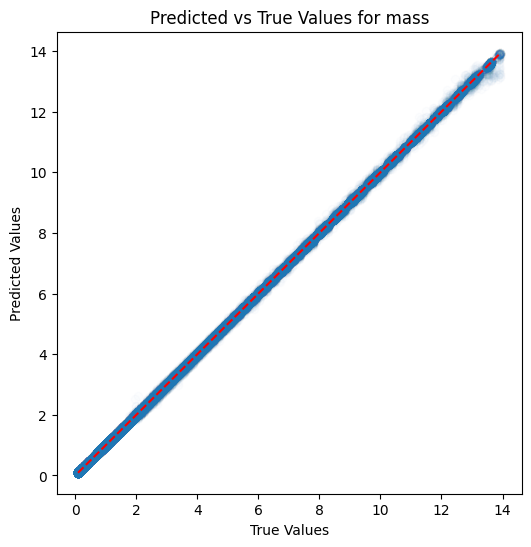

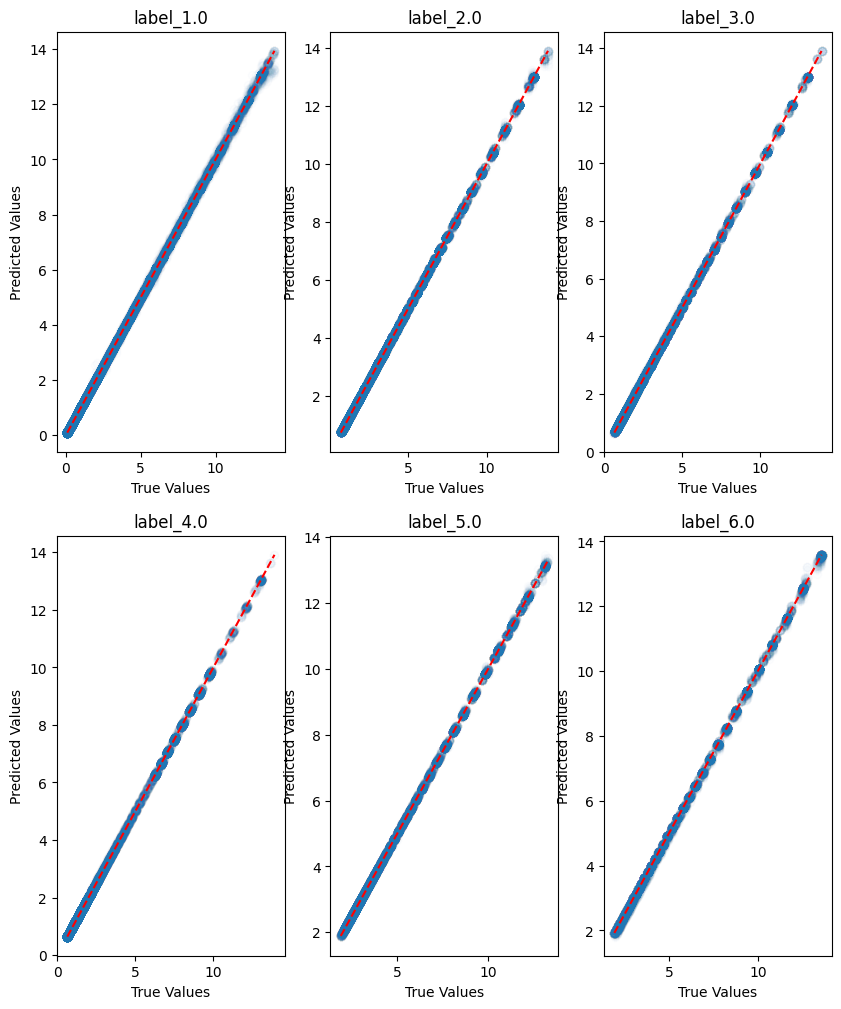

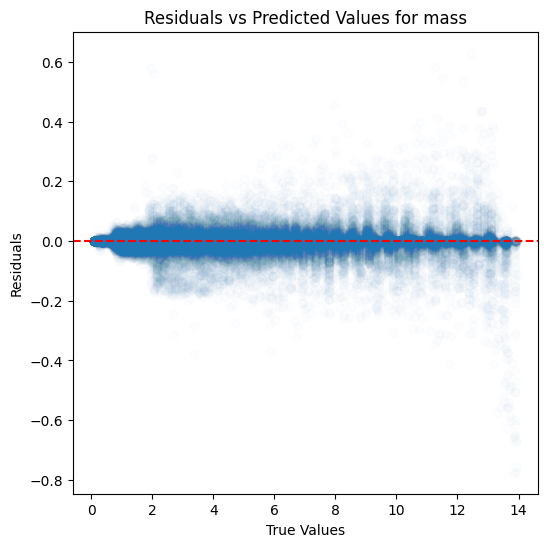

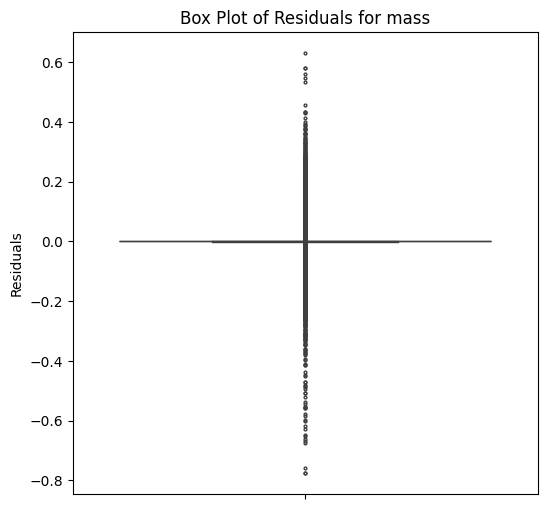

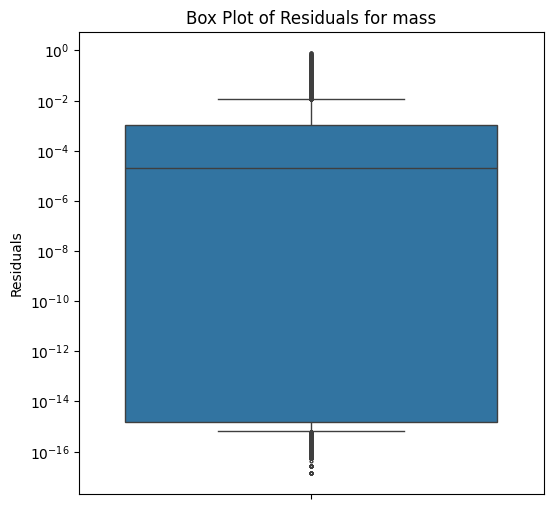

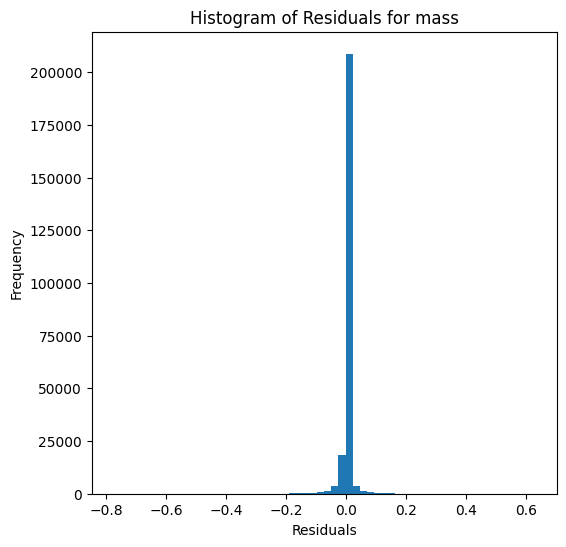

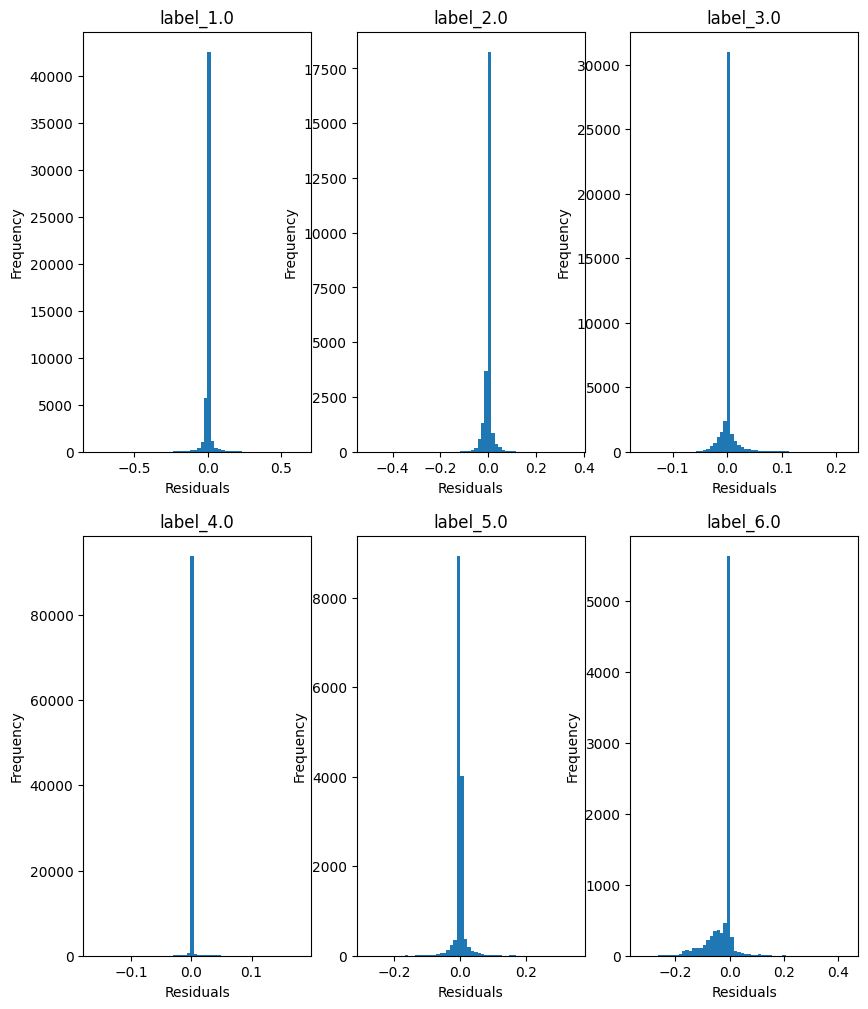

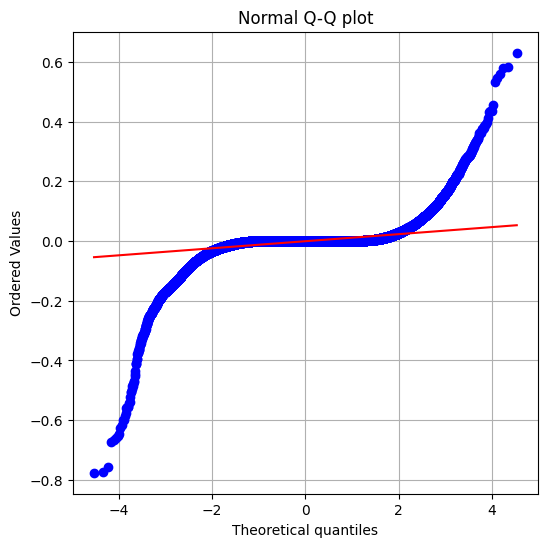

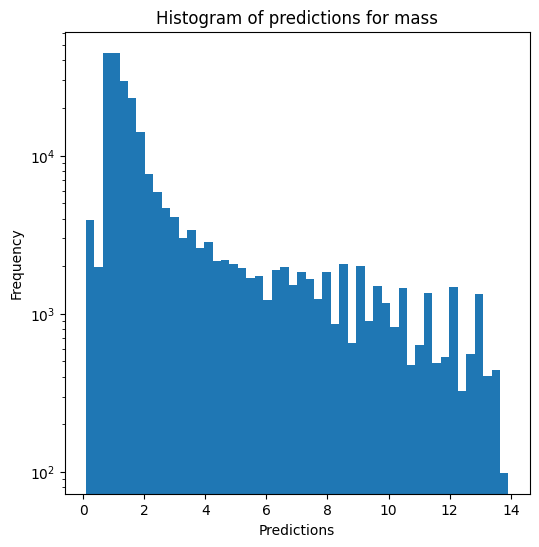

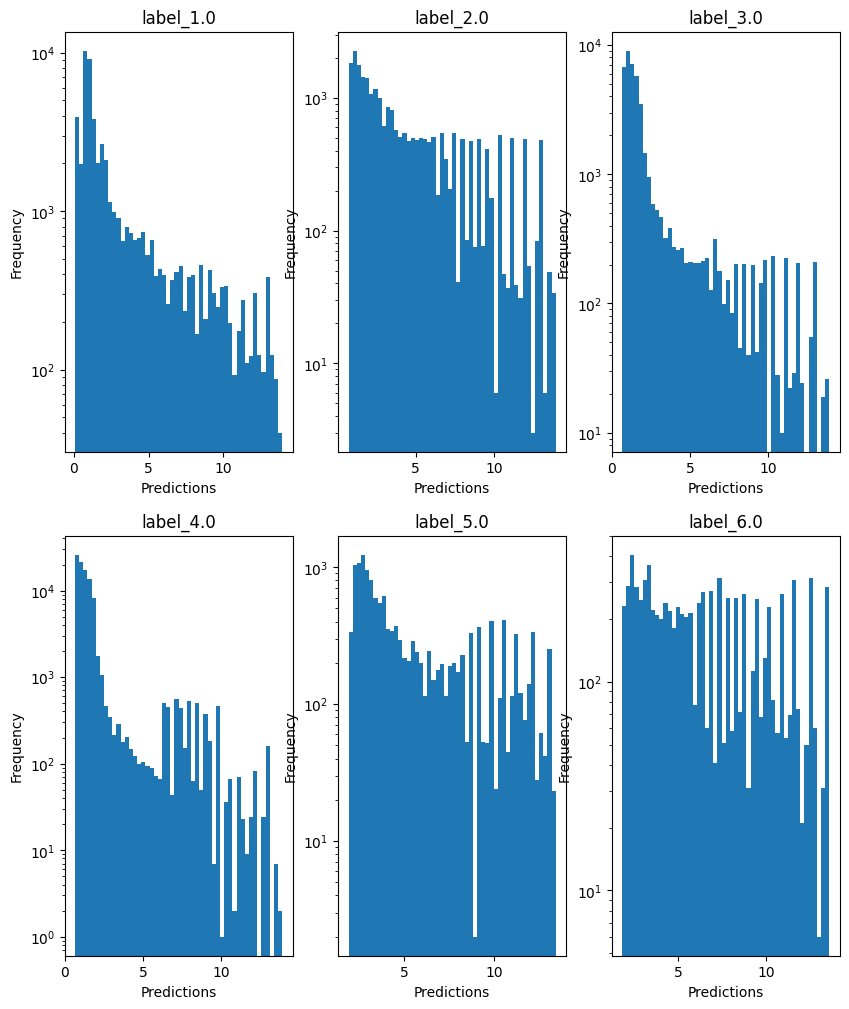

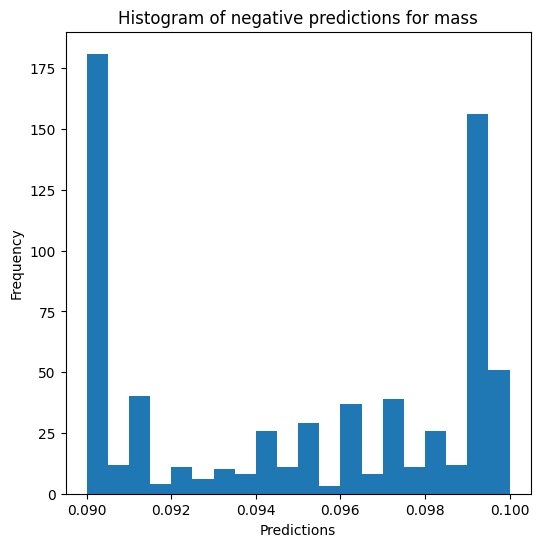


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9999182294661465
  RMSE :  0.0033093822318584374
  MAE :  0.0013150842165456564
  MedAE :  0.0001760810941121016
  CORR :  0.9999591824692355
  MAX_ER :  0.07319970152014169
  Percentiles : 
    75th percentile :  0.0010786006582953808
    90th percentile :  0.003974546282406385
    95th percentile :  0.006737124234101843
    99th percentile :  0.014721559884541324

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9997637676842808
  RMSE :  0.008347006809968886
  MAE :  0.002827904460205892
  MedAE :  0.0004557941470076654
  CORR :  0.9998863034979152
  MAX_ER :  0.27389005778331077
  Percentiles : 
    75th percentile :  0.0027078089269516603
    90th percentile :  0.007820639945842676
    95th percentile :  0.012036058611177628
    99th percentile :  0.028887769499043144

radius resu

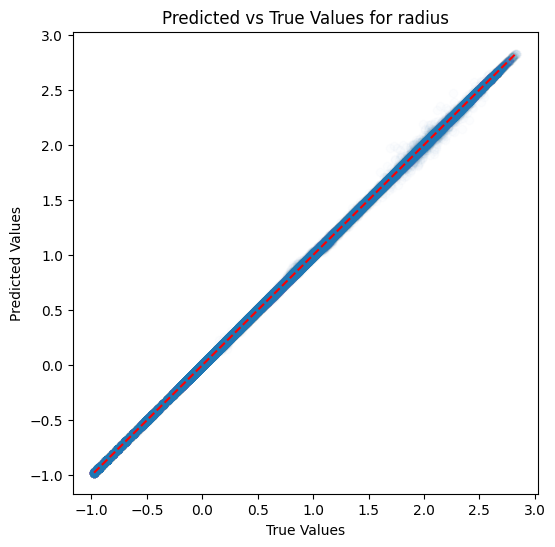

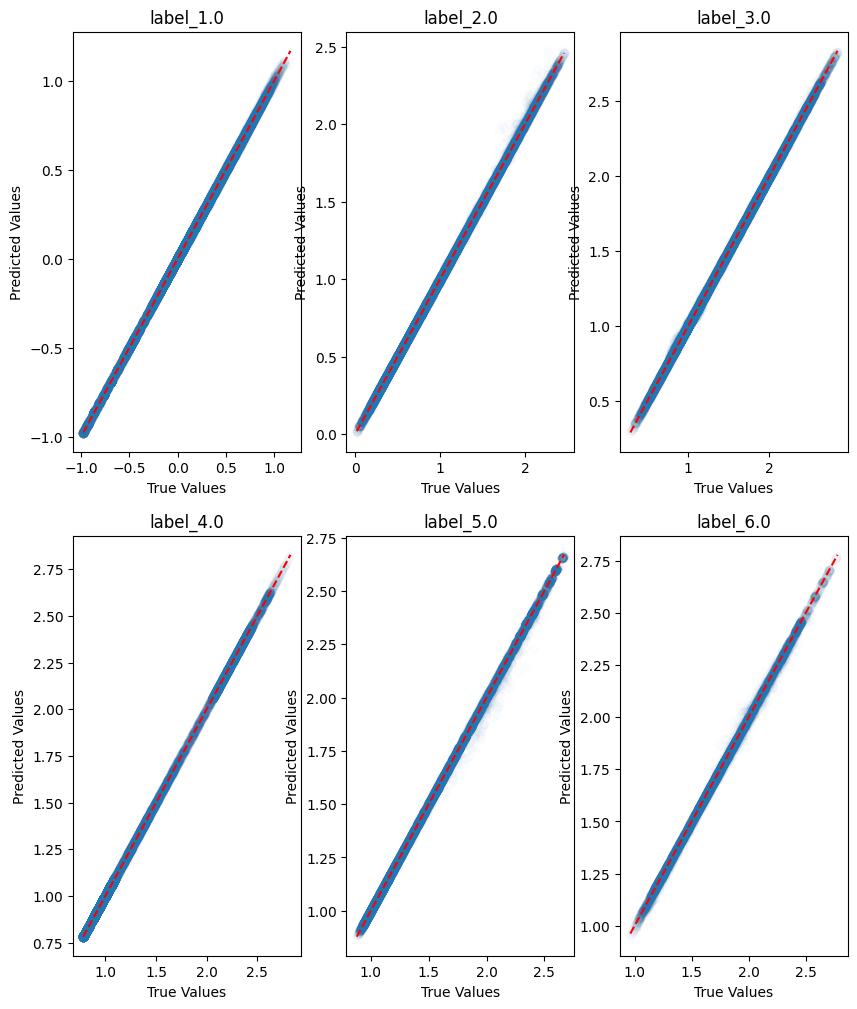

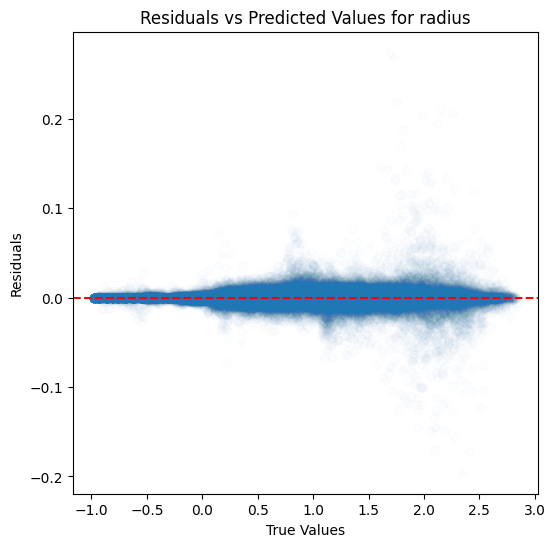

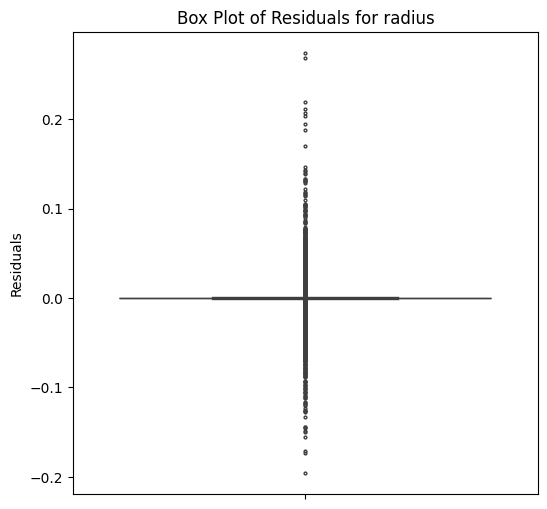

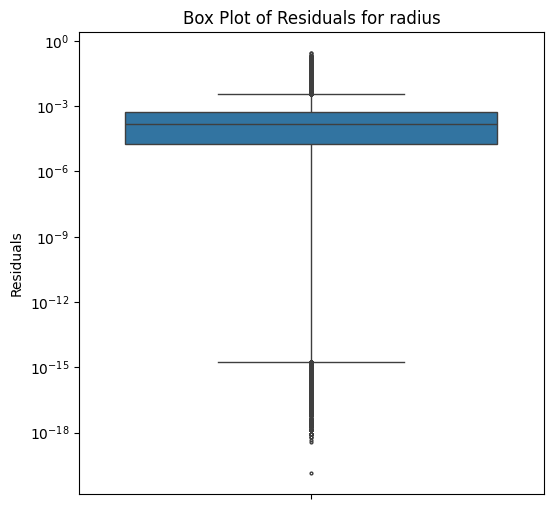

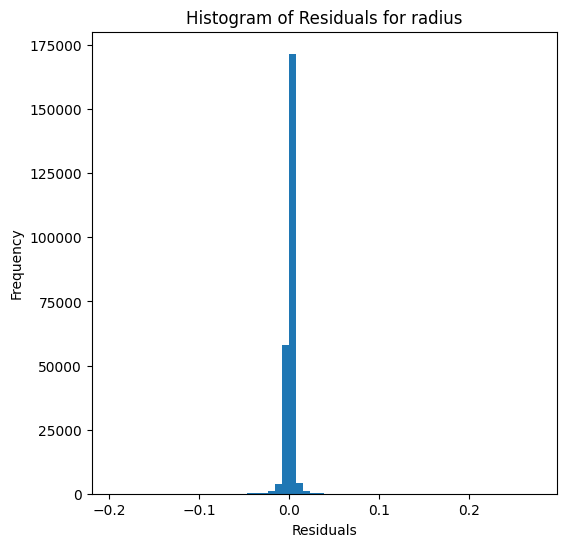

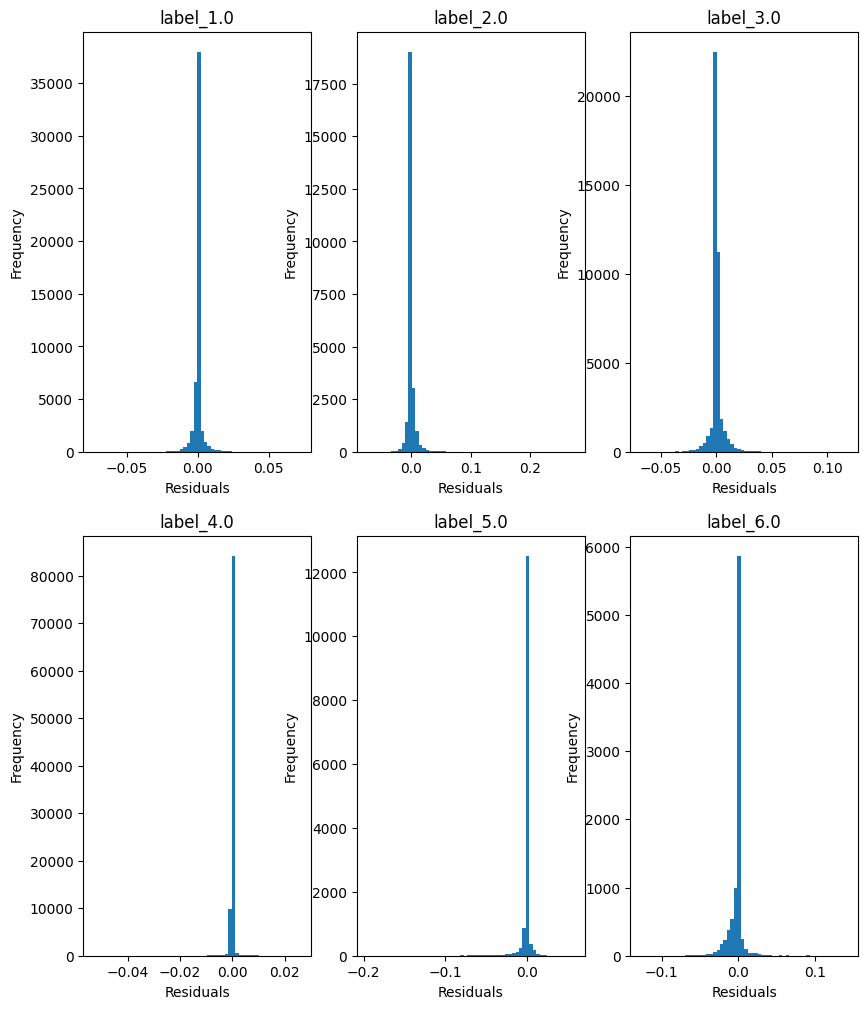

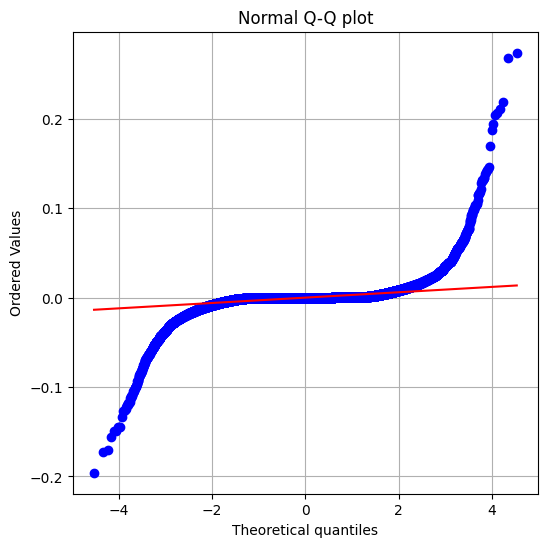

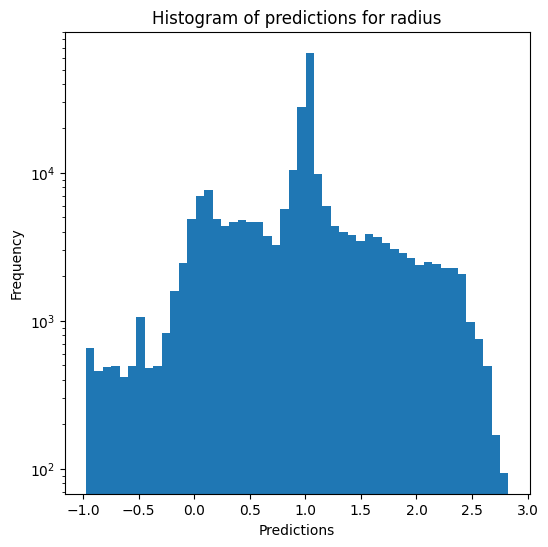

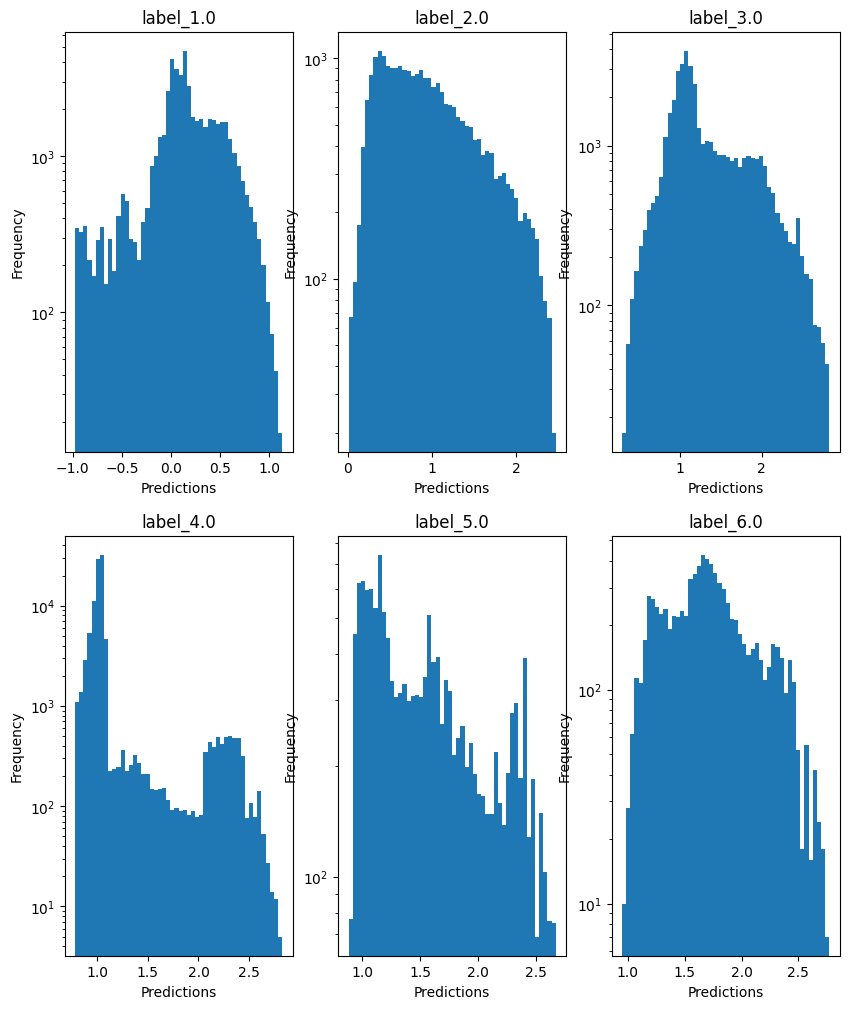

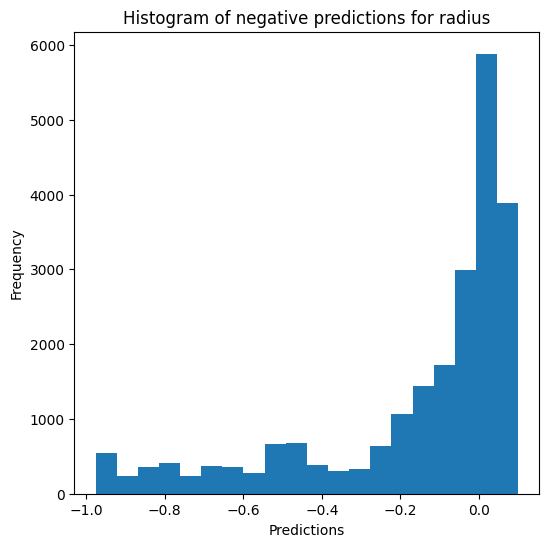

Saving predictions and results...


In [17]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)
# average depth de 44-46

### XGBoost

In [18]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9991350851722829
  RMSE :  0.0887554156625211
  MAE :  0.046886387633201056
  MedAE :  0.020626248836517425
  CORR :  0.999567813034968
  MAX_ER :  1.4695928878784184
  Percentiles : 
    75th percentile :  0.05201218032836952
    90th percentile :  0.11996983242034909
    95th percentile :  0.18982356643676757
    99th percentile :  0.37039495620727525

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.999888070822217
  RMSE :  0.03612342170599431
  MAE :  0.02399718580019451
  MedAE :  0.01514275693893452
  CORR :  0.9999466740441237
  MAX_ER :  0.3200783462524406
  Percentiles : 
    75th percentile :  0.031249127388000564
    90th percentile :  0.05624012413024876
    95th percentile :  0.07732287445068352
    99th percentile :  0.12993

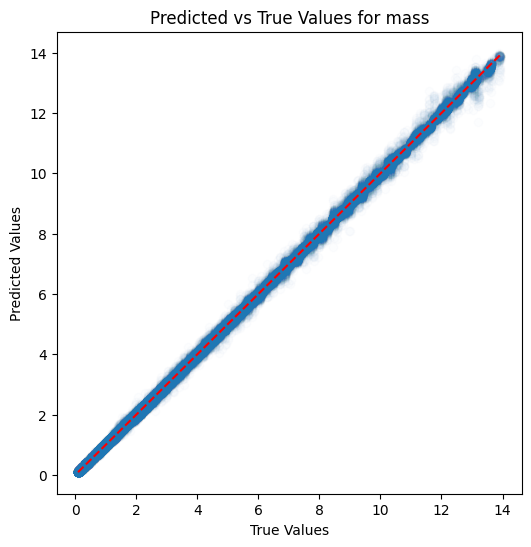

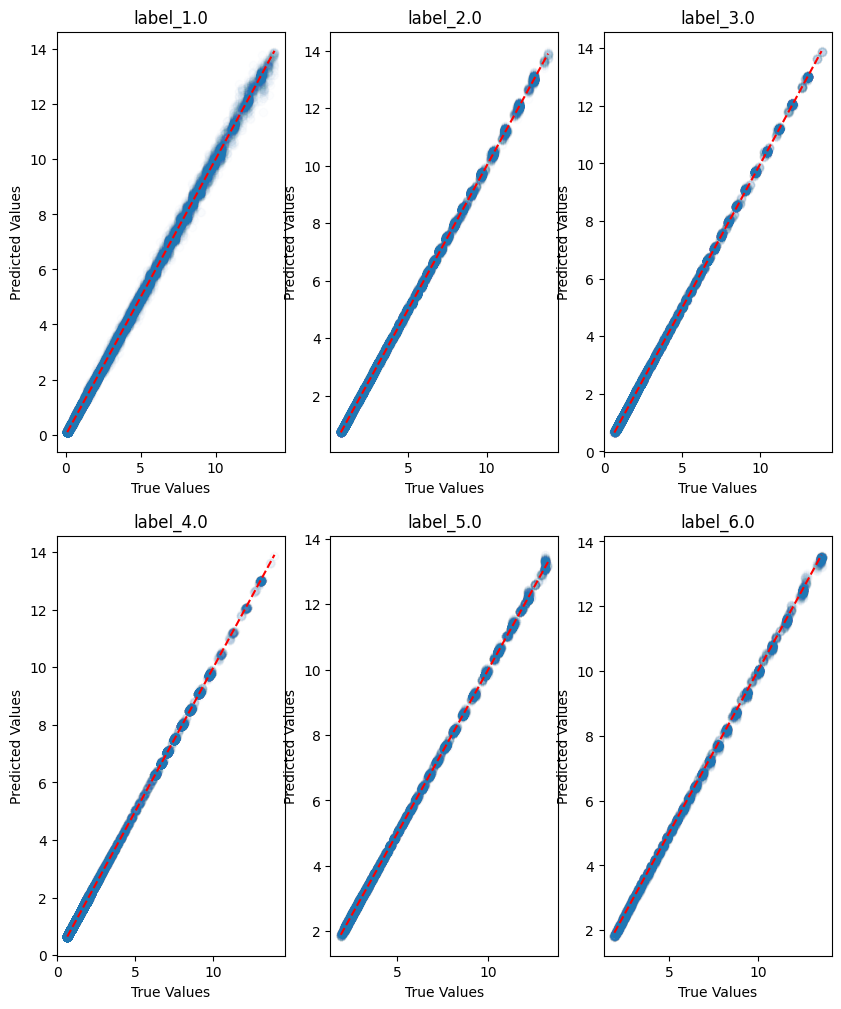

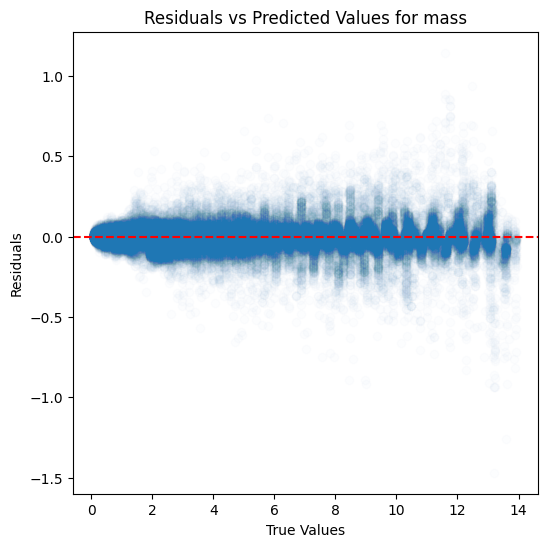

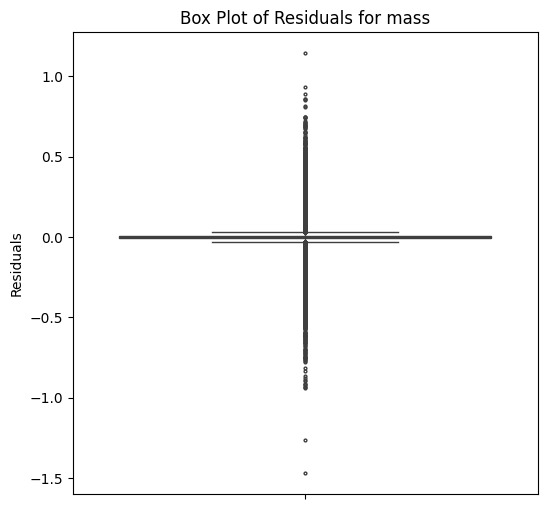

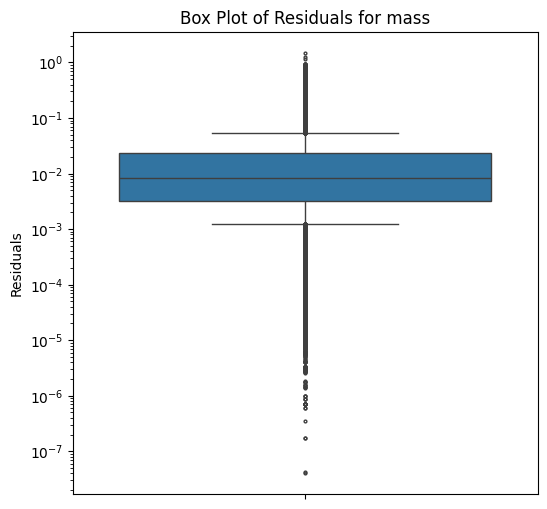

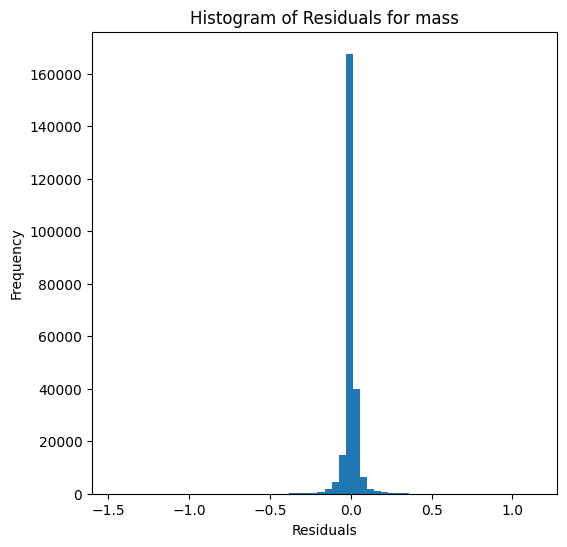

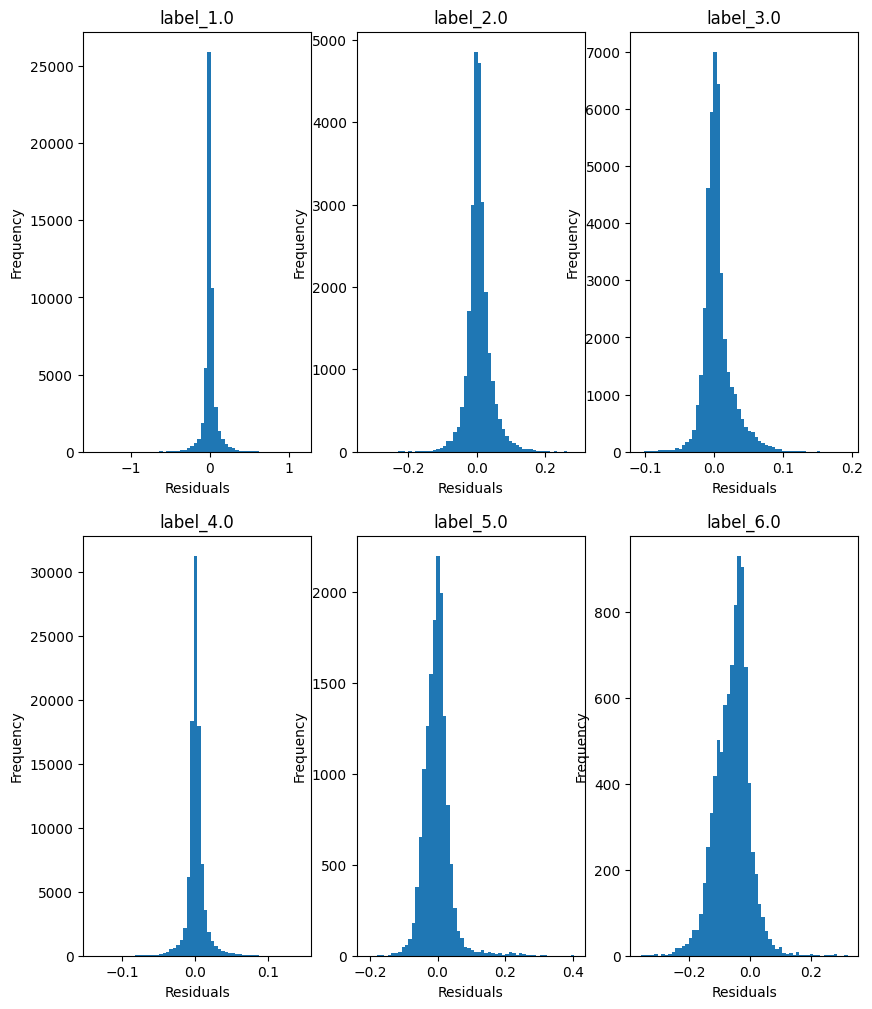

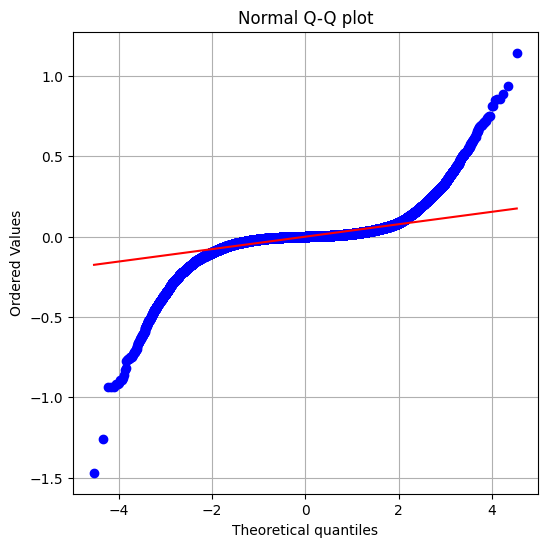

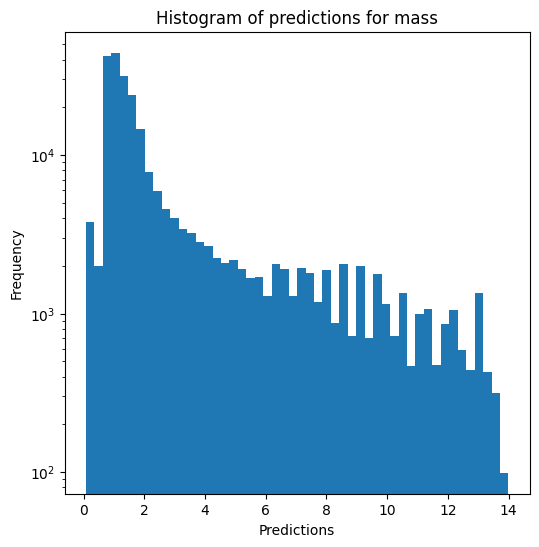

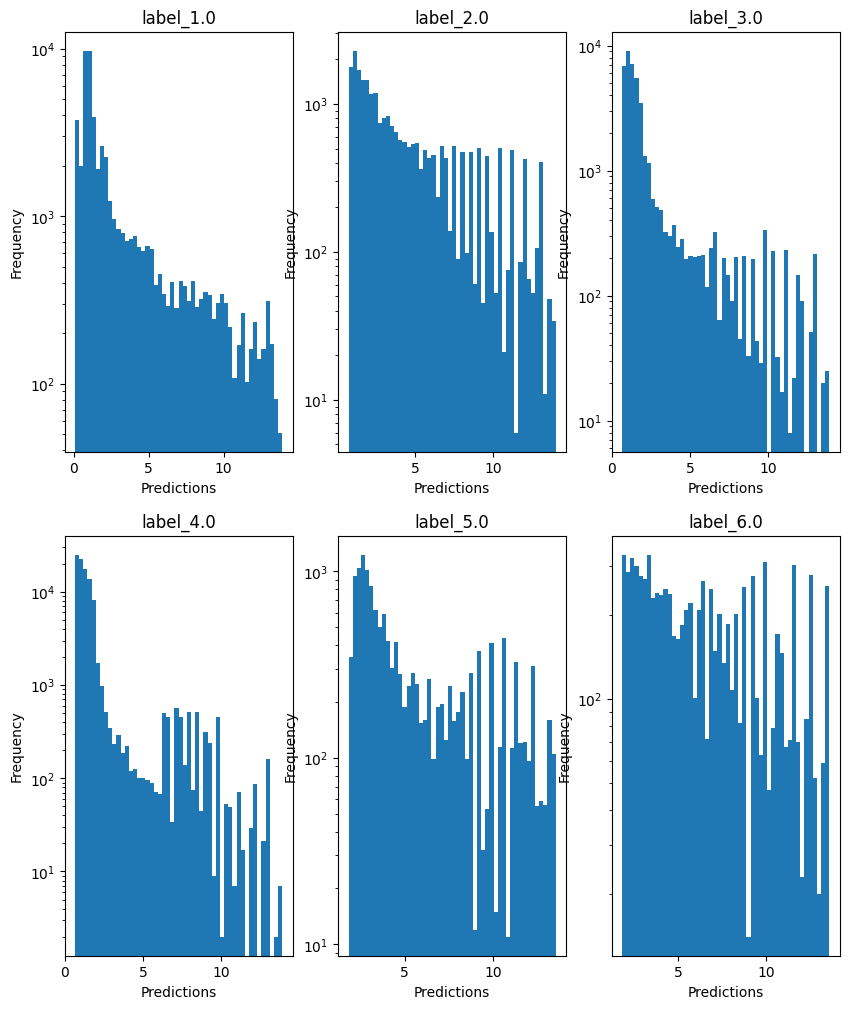

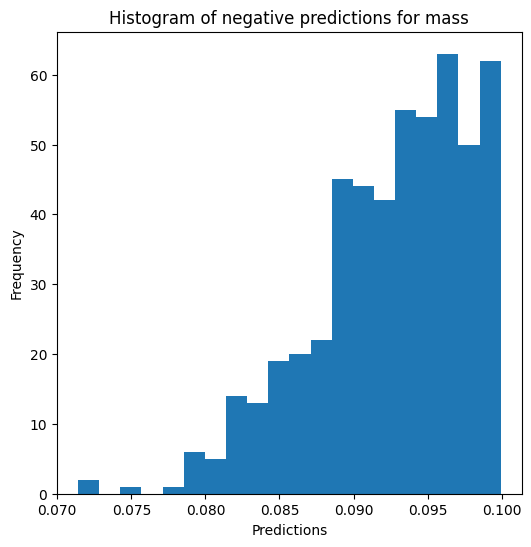


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.99924952821124
  RMSE :  0.010025829454064671
  MAE :  0.006851980137943696
  MedAE :  0.004714362388504166
  CORR :  0.9996247501188131
  MAX_ER :  0.08896295685255406
  Percentiles : 
    75th percentile :  0.009184591126604955
    90th percentile :  0.015166520496588815
    95th percentile :  0.02010547089875027
    99th percentile :  0.03502351341217506

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9994404577145701
  RMSE :  0.01284990524417628
  MAE :  0.009512662463685836
  MedAE :  0.007496822958309862
  CORR :  0.9997269256609371
  MAX_ER :  0.15352155580429705
  Percentiles : 
    75th percentile :  0.013189632936975615
    90th percentile :  0.019703675985482158
    95th percentile :  0.024772533746863855
    99th percentile :  0.03776110700516406

radius results for the 

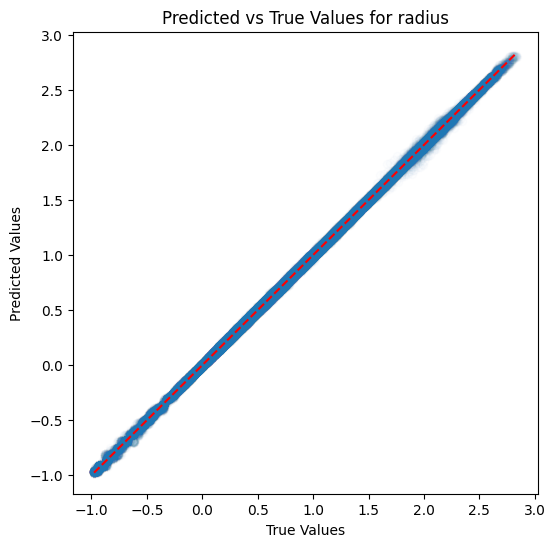

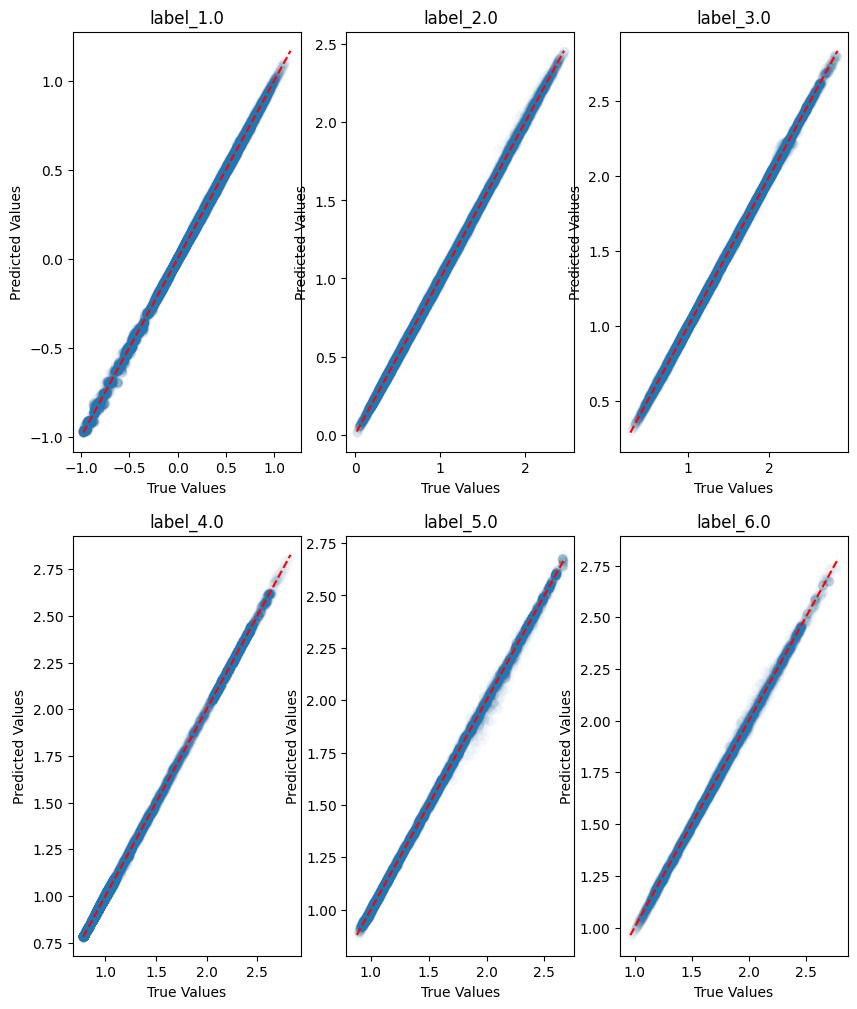

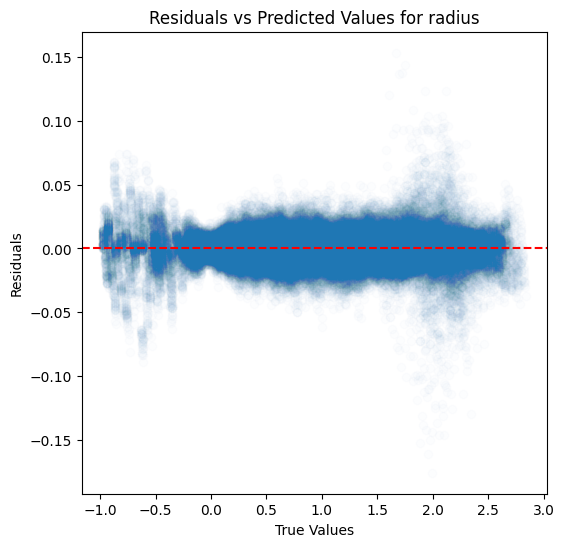

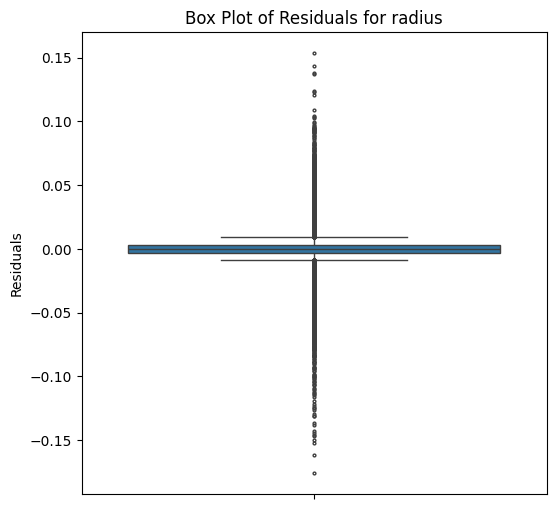

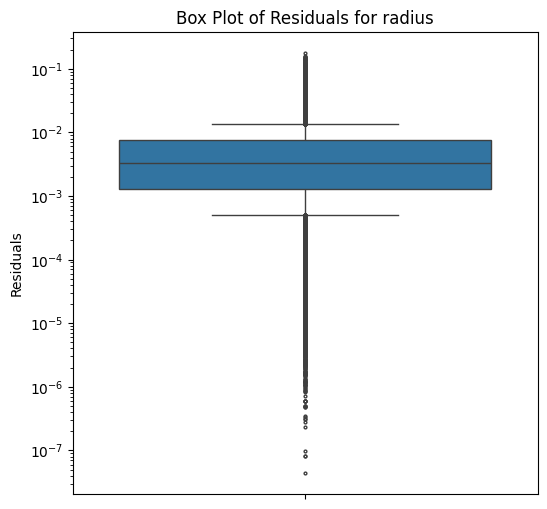

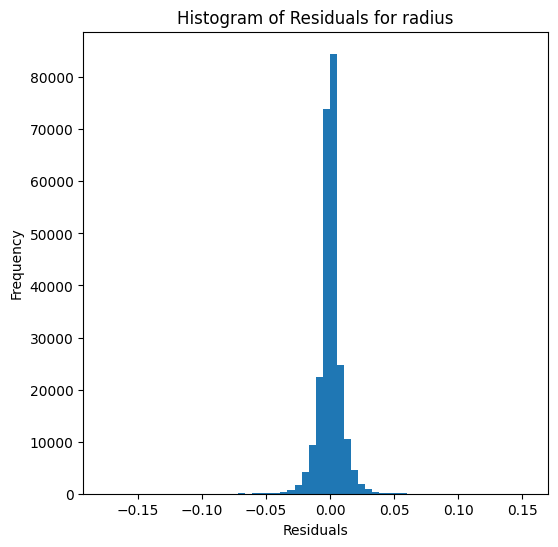

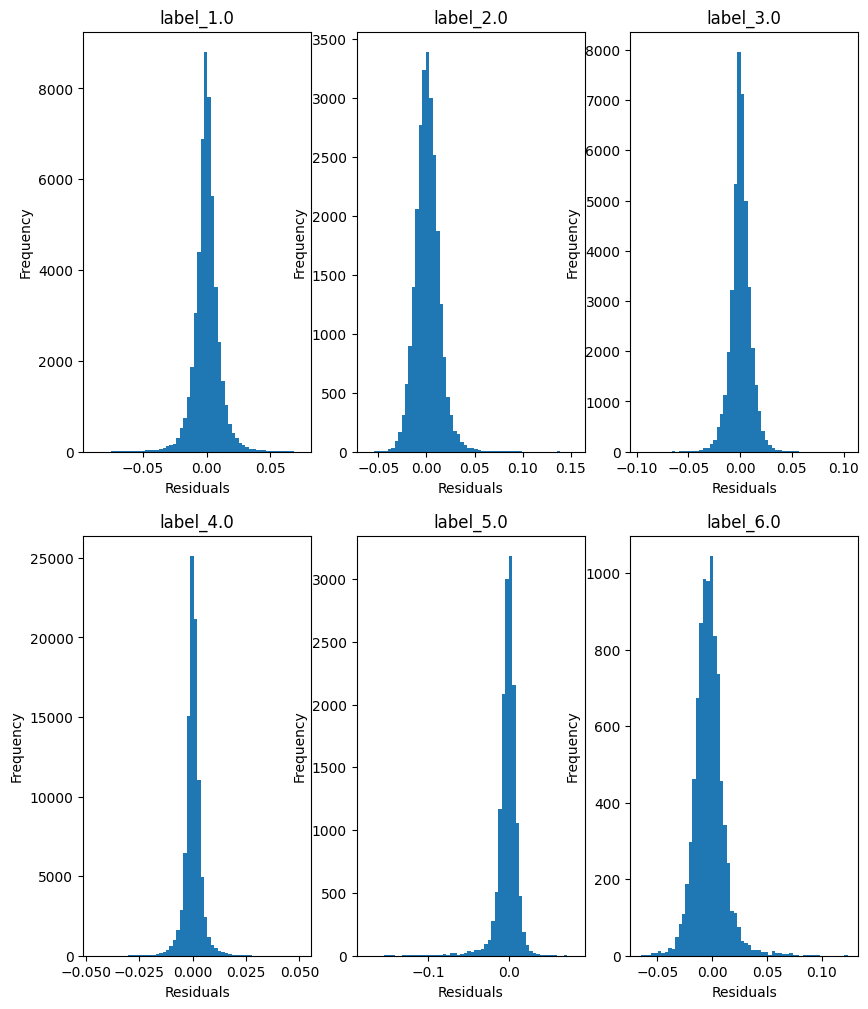

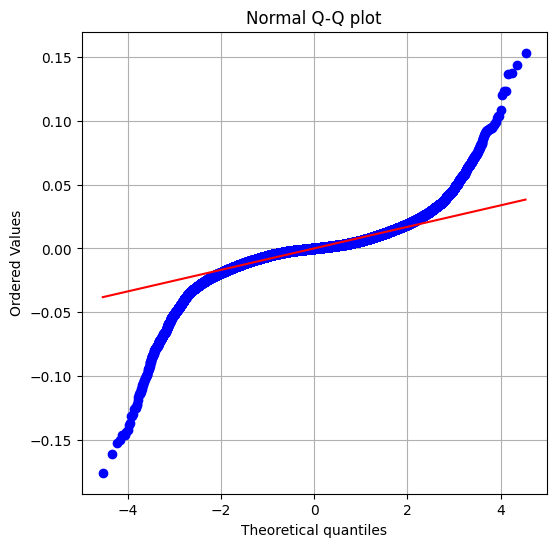

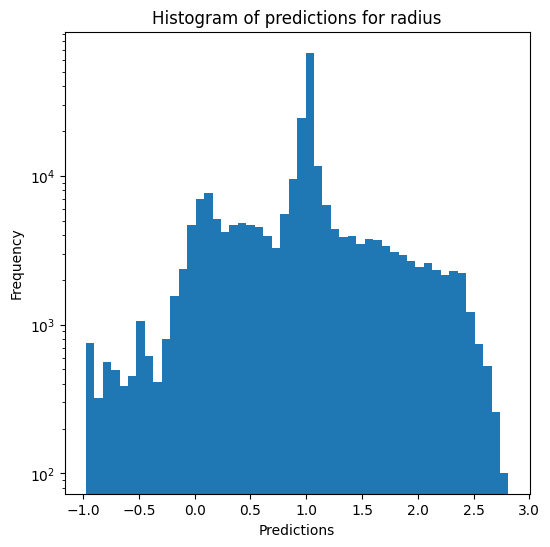

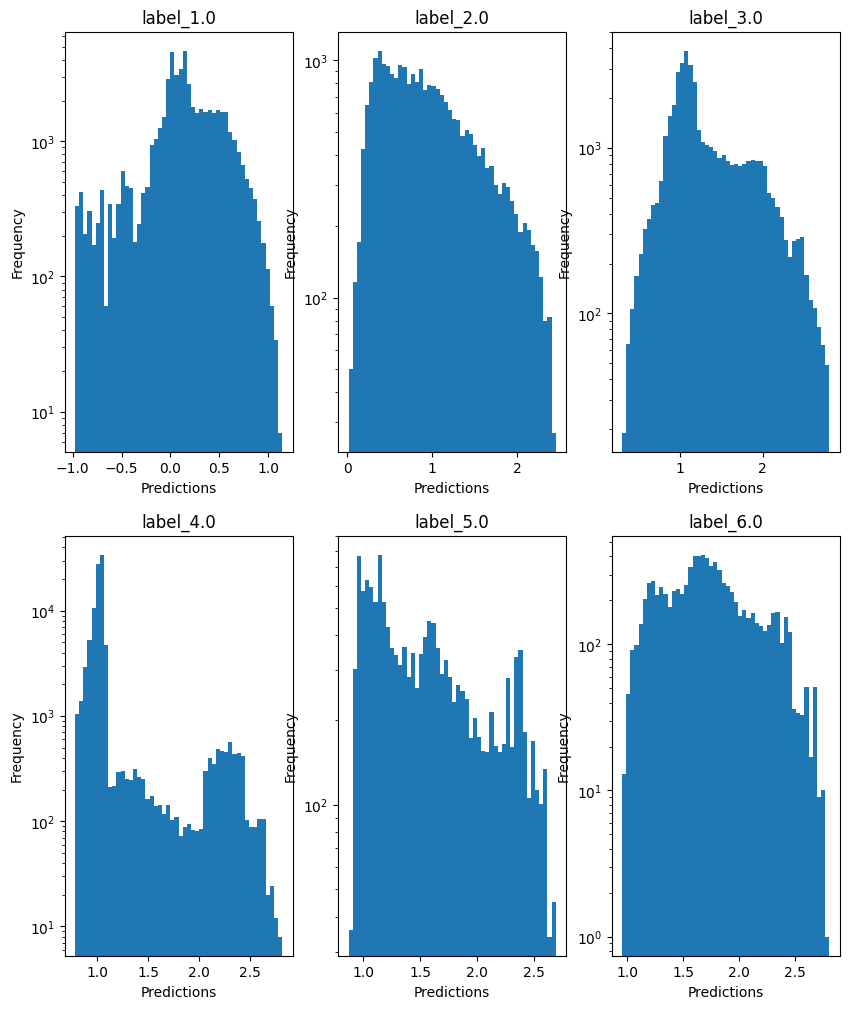

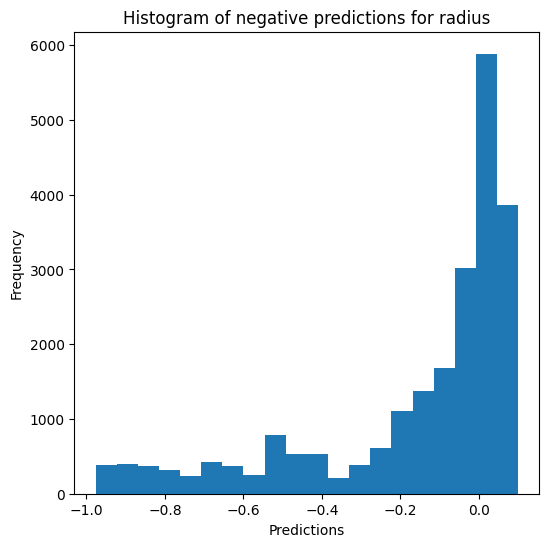

Saving predictions and results...


In [19]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [20]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust train data :
Performing K-fold...
Split 1 0.00045470065466879486
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.00048202044468887475
3 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0003542259331576429
4 0.00042090361135969885
5 0.00047696572642450143

Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9993973107787721
  RMSE :  0.07477435137967348
  MAE :  0.028645366587864693
  MedAE :  0.01171850623002213
  CORR :  0.9997485635062454
  MAX_ER :  1.2590320504076402
  Percentiles : 
    75th percentile :  0.023770896093530725
    90th percentile :  0.055461035390697244
    95th percentile :  0.10257705309665788
    99th percentile :  0.3679681320756586

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9992769593433143
  RMSE :  0.09125624650966614
  MAE :  0.04497916634194317
  MedAE :  0.019536986264115486
  CORR :  0.9996670224817525
  MAX_ER :  0.9765675996623564
  Percentiles : 
    75th percentile :  0.044826302832935316
    90th percentile :  0.10773973814986597
    95th percentile :  0.17370601268009989
    99th percentile :  0.4160

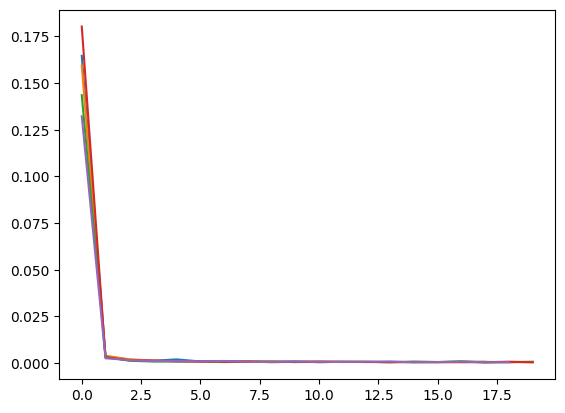

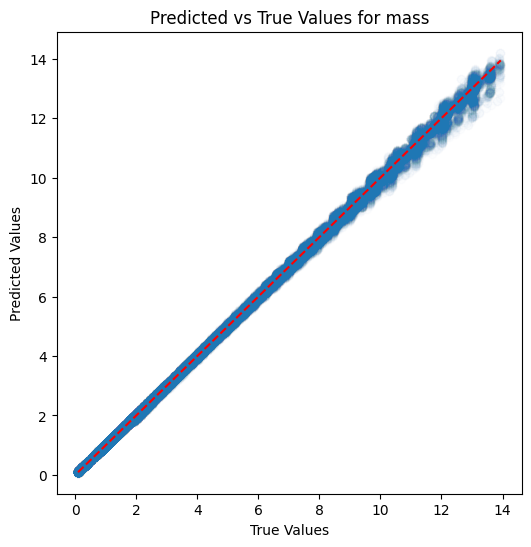

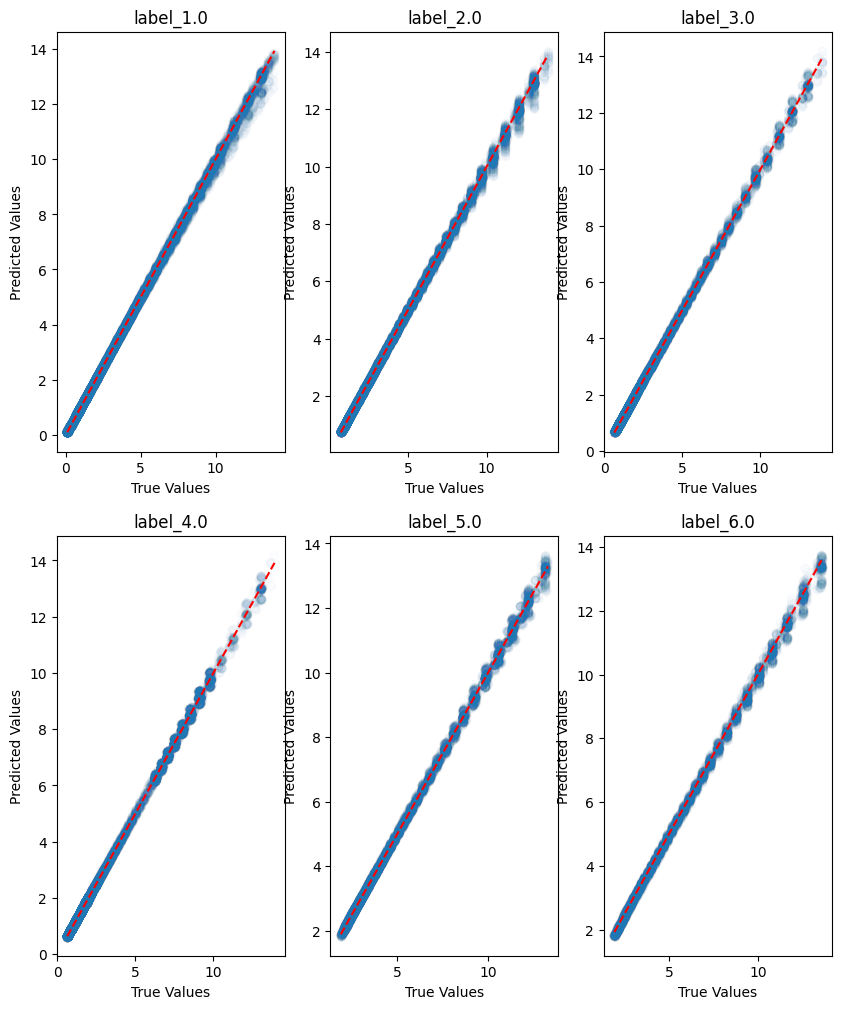

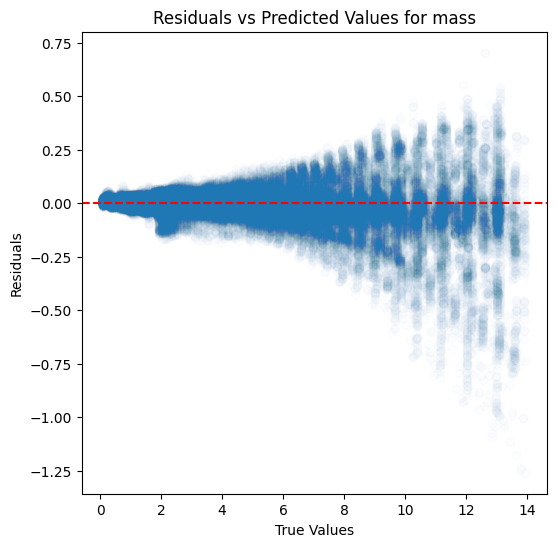

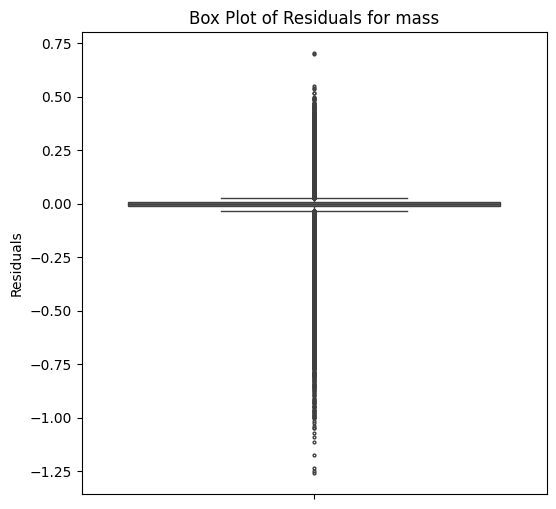

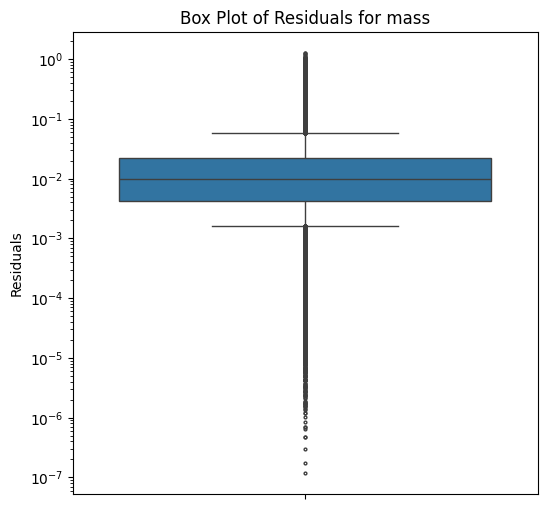

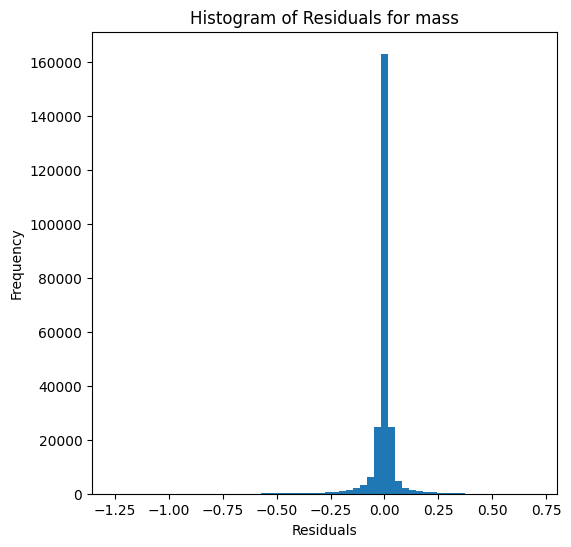

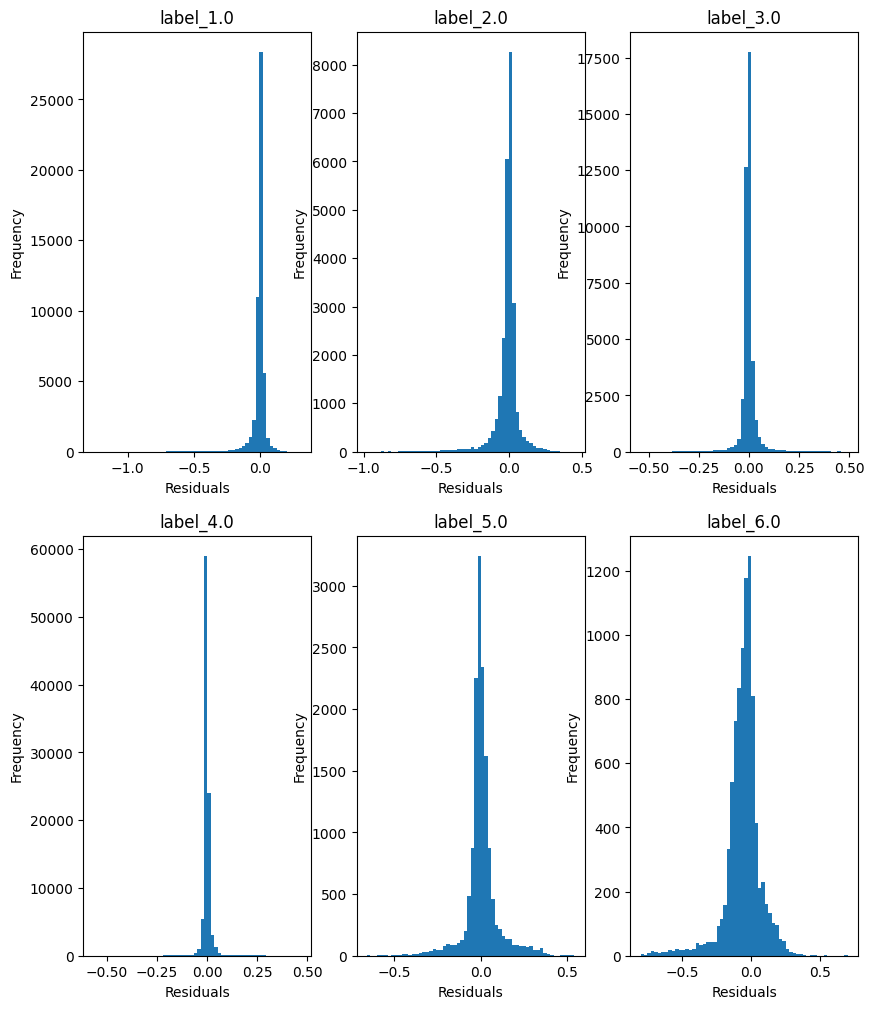

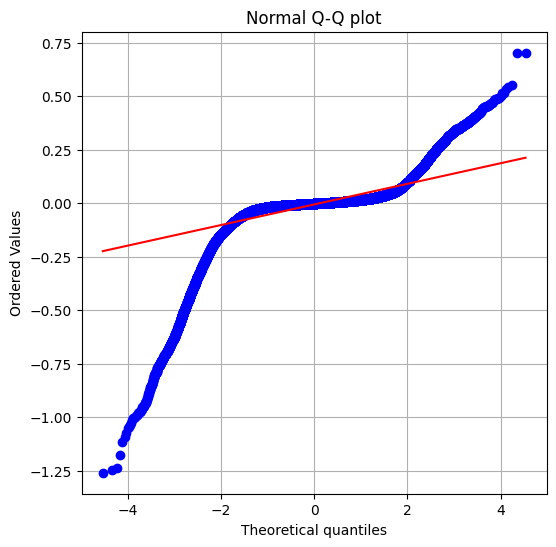

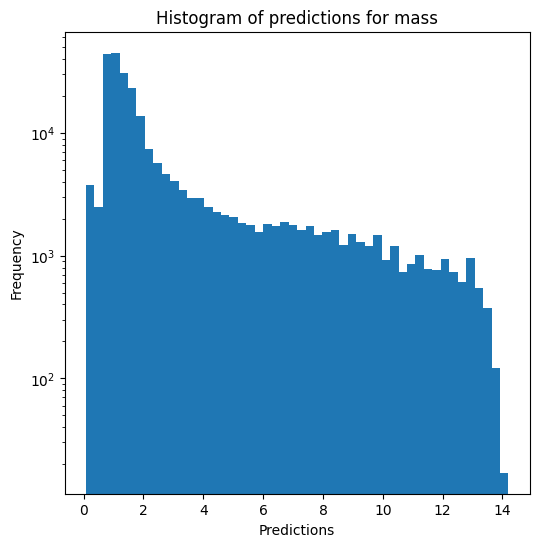

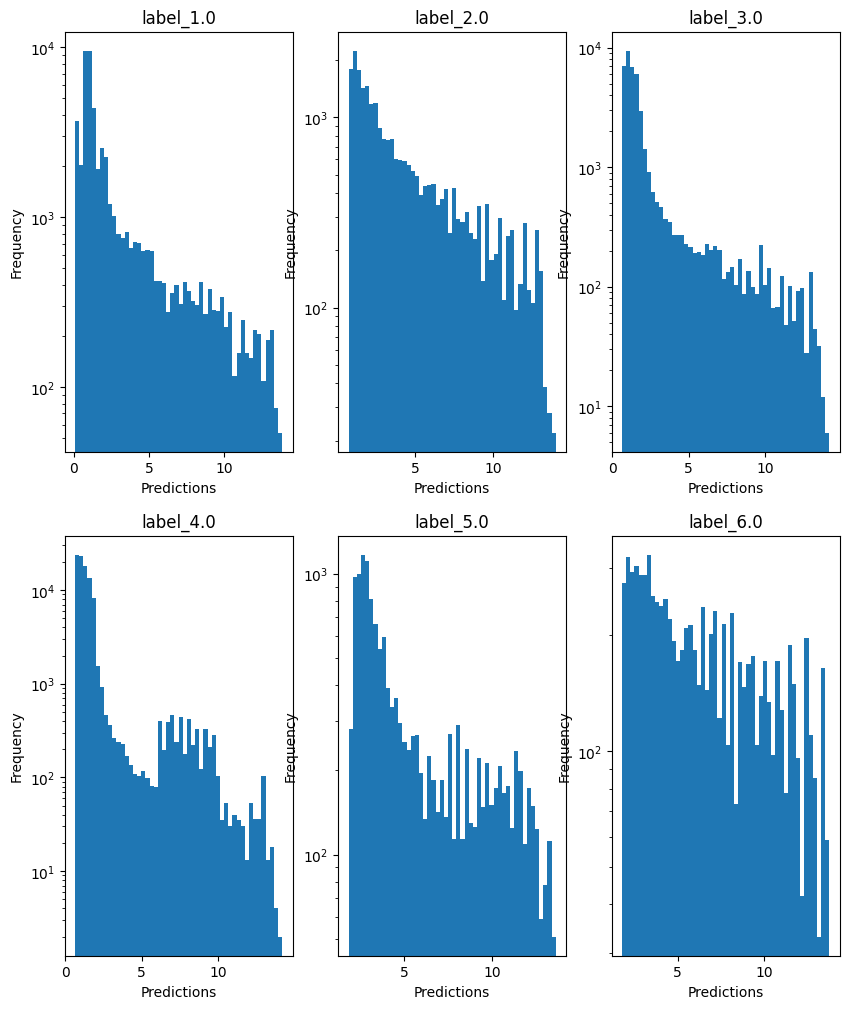

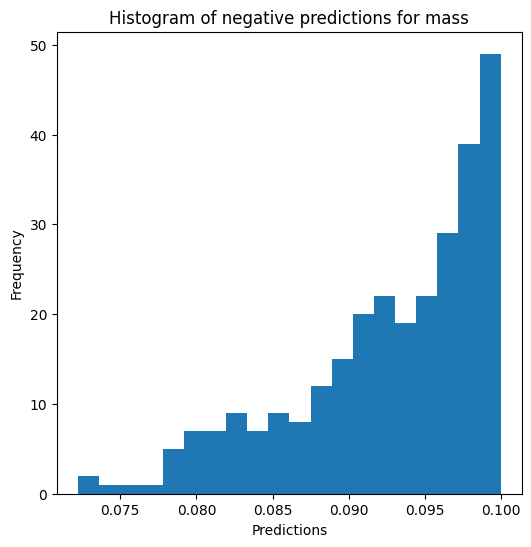


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9990966385699608
  RMSE :  0.010999669318713682
  MAE :  0.00838366376446122
  MedAE :  0.006756127208913912
  CORR :  0.9995528845430164
  MAX_ER :  0.07415767099625514
  Percentiles : 
    75th percentile :  0.011356712080878899
    90th percentile :  0.017227223371590883
    95th percentile :  0.021721065215935226
    99th percentile :  0.03429564842372678

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9993371417647371
  RMSE :  0.013992845733625433
  MAE :  0.010357311177448543
  MedAE :  0.00816737483791441
  CORR :  0.9996724301422015
  MAX_ER :  0.08310391467221034
  Percentiles : 
    75th percentile :  0.013966113147885748
    90th percentile :  0.020992178241152244
    95th percentile :  0.027039958983976688
    99th percentile :  0.048791337190506

radius results for the 

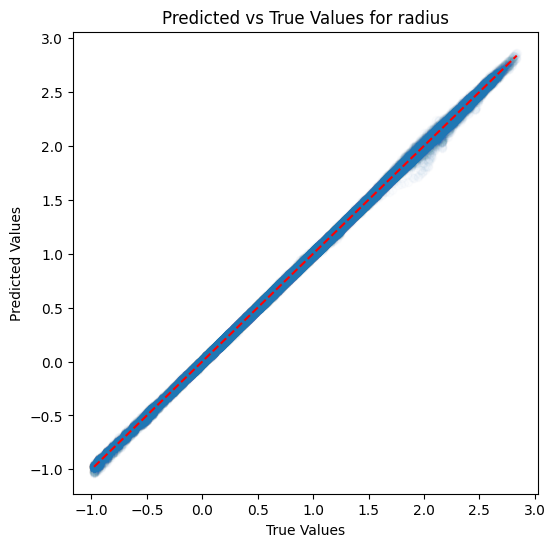

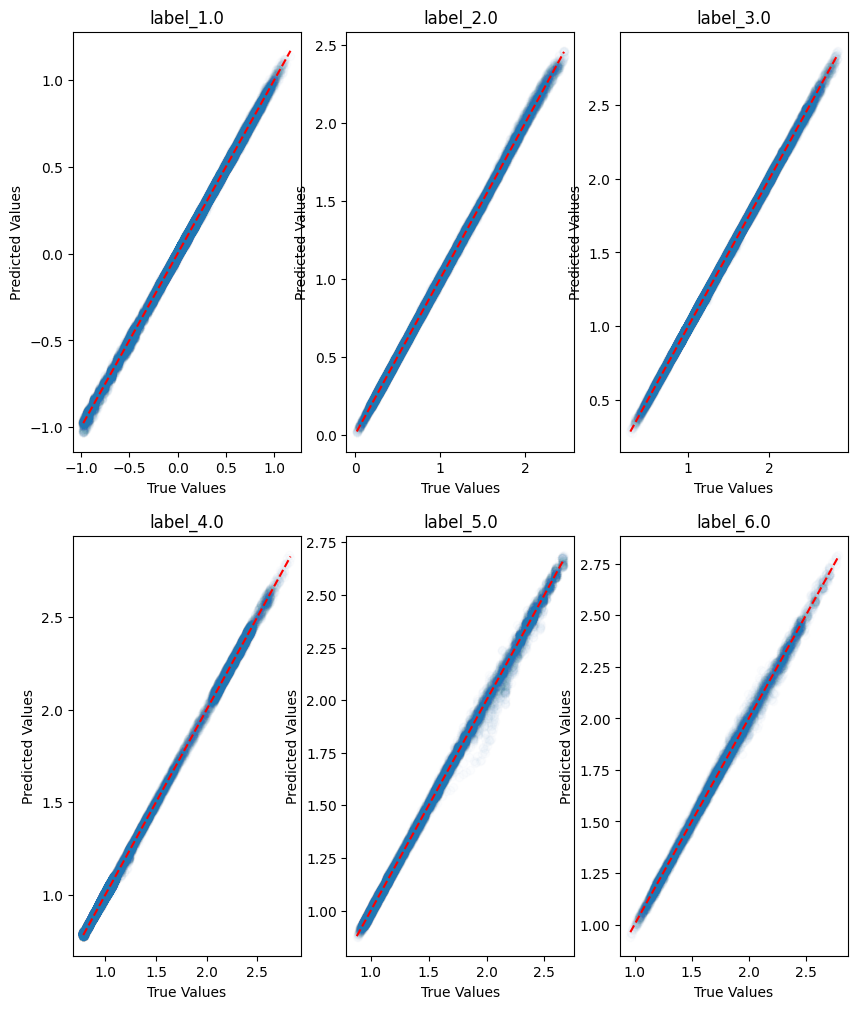

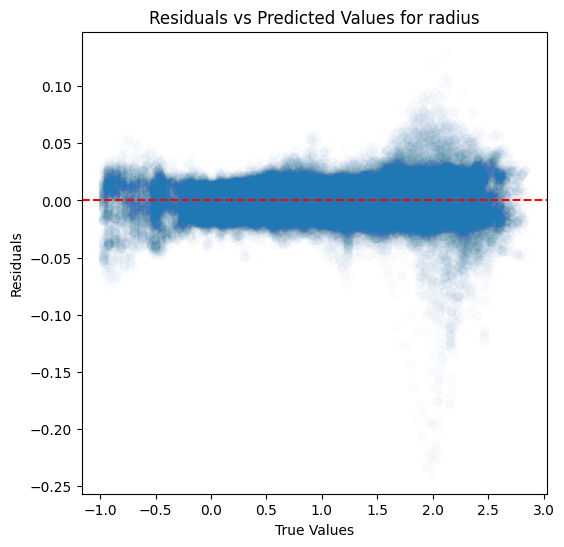

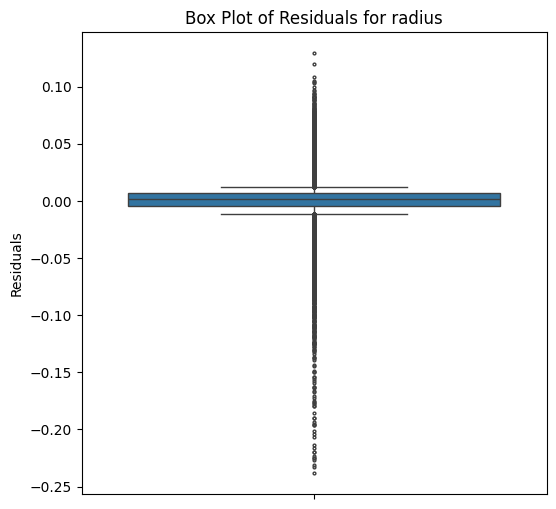

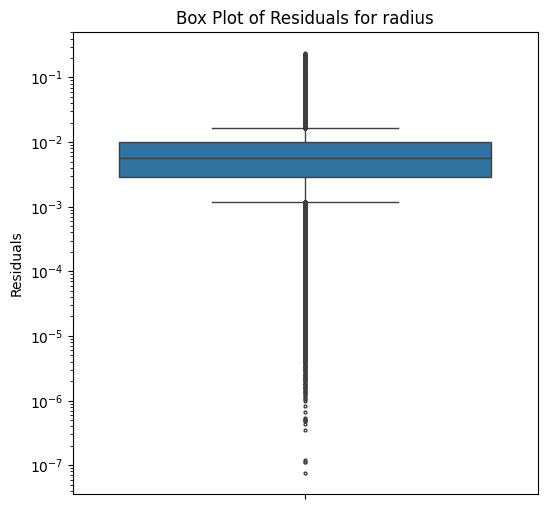

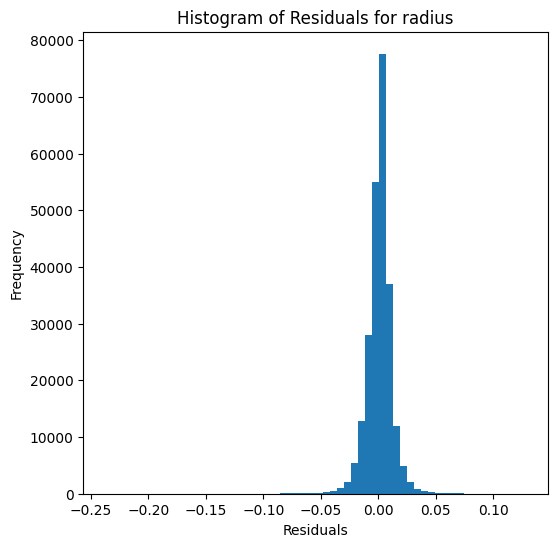

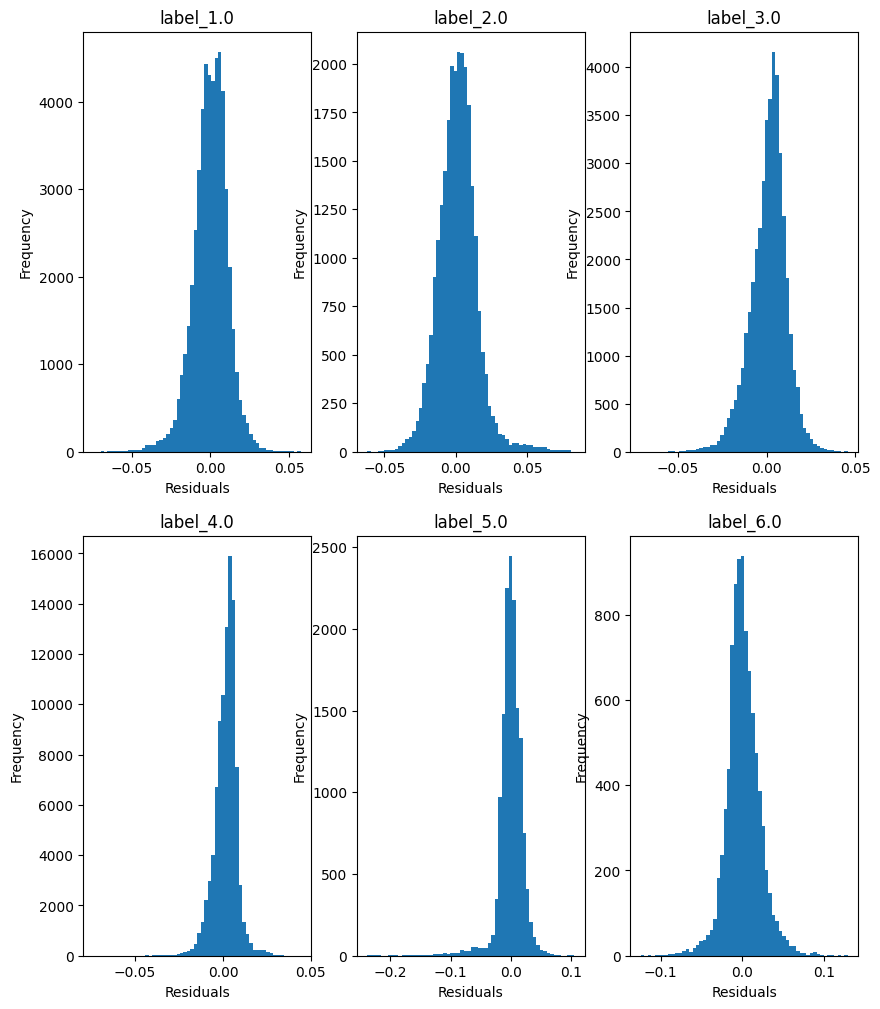

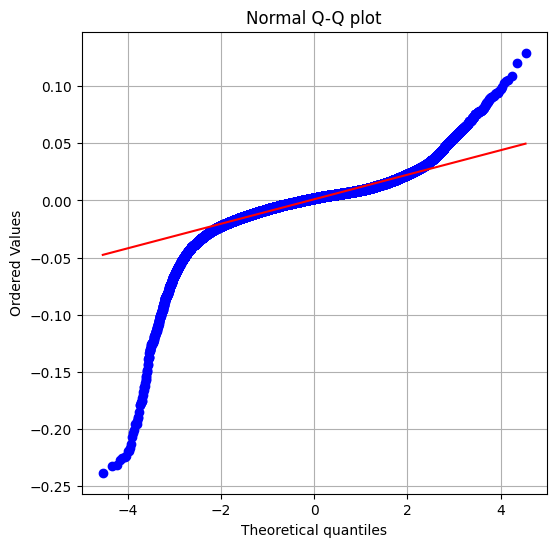

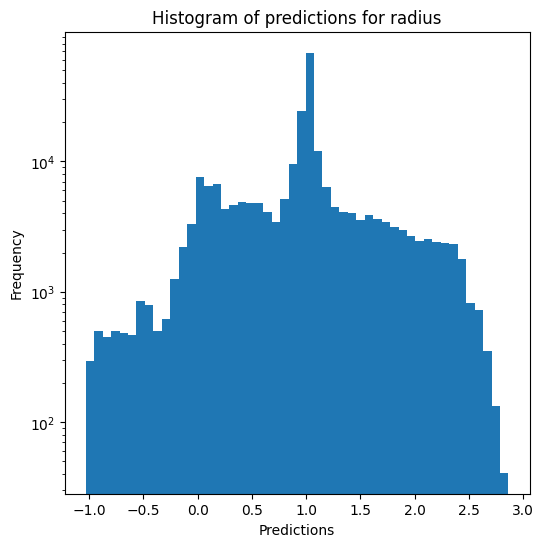

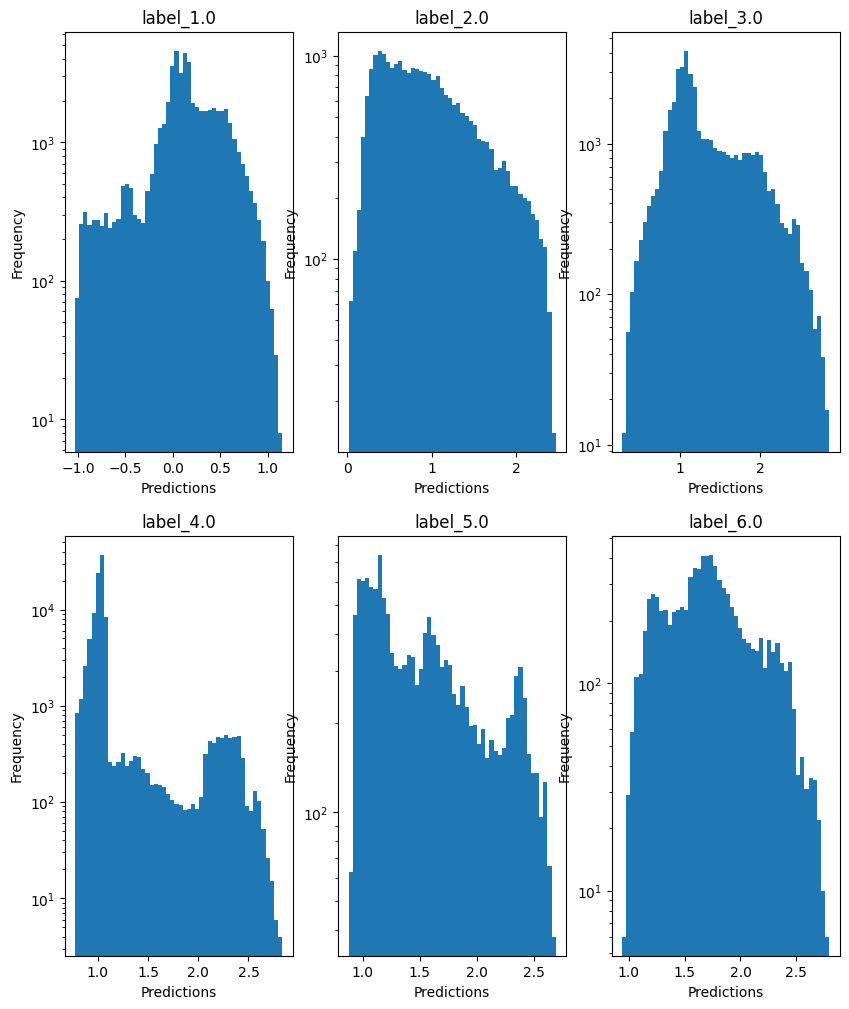

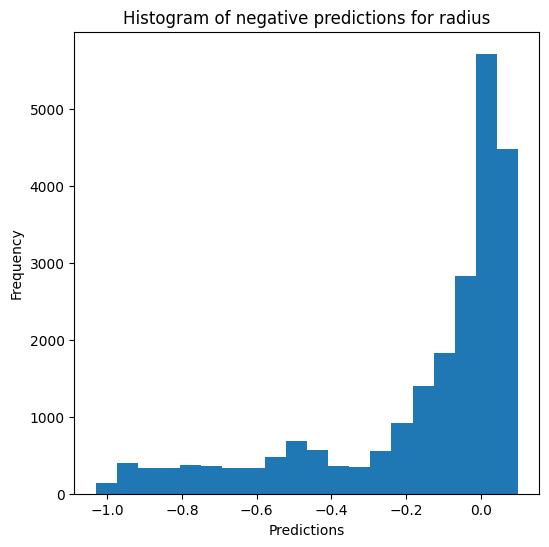

Saving predictions and results...


In [21]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, scaler_name=scaler_name, show=show,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon